# Lab 10 — Métodos de Propagación de Etiquetas
**Grupo 03** | Minería de Datos — Sección 20  
Universidad del Valle de Guatemala

**Integrantes:** Felipe Aguilar, Vianka Castro, Nicolás Concuá, Ricardo Godínez, Fernando Hernández, Fernando Rueda

---

## Fase 2 — Selección y Análisis de Dataset

**Dataset:** Red Wine Quality  
**Fuente:** UCI Machine Learning Repository / Kaggle  
**Algoritmos a aplicar:** Label Propagation & Label Spreading

---
## 2a. Importación del Dataset

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('winequality-red.csv', sep=';')

print('Dataset cargado exitosamente.')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

Dataset cargado exitosamente.
Dimensiones: 1599 filas x 12 columnas


In [2]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print('Columnas del dataset:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

Columnas del dataset:
   1. fixed acidity
   2. volatile acidity
   3. citric acid
   4. residual sugar
   5. chlorides
   6. free sulfur dioxide
   7. total sulfur dioxide
   8. density
   9. pH
  10. sulphates
  11. alcohol
  12. quality


In [4]:
feature_cols = [c for c in df.columns if c != 'quality']
X = df[feature_cols]
y_raw = df['quality']

df['quality_label'] = (df['quality'] >= 7).astype(int)
df['quality_str']   = df['quality_label'].map({0: 'bad', 1: 'good'})
y = df['quality_label']

print(f'Features : {len(feature_cols)}')
print(f'Target   : quality binarizado (>=7 = good, <7 = bad)')
print(f'Muestras : {len(df)}')

Features : 11
Target   : quality binarizado (>=7 = good, <7 = bad)
Muestras : 1599


---
## 2b. Análisis Exploratorio de Datos (EDA)

### Tipos de variables y dimensionalidad

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

In [6]:
type_summary = pd.DataFrame({
    'dtype'      : df[feature_cols].dtypes,
    'non_null'   : df[feature_cols].notna().sum(),
    'null'       : df[feature_cols].isna().sum(),
    'unique_vals': df[feature_cols].nunique()
})

print('=== Resumen de tipos de variables ===')
print(type_summary.to_string())
print(f'\nFeatures numericas  : {df[feature_cols].select_dtypes(include=np.number).shape[1]}')
print(f'Features categoricas: {df[feature_cols].select_dtypes(include="object").shape[1]}')

=== Resumen de tipos de variables ===
                        dtype  non_null  null  unique_vals
fixed acidity         float64      1599     0           96
volatile acidity      float64      1599     0          143
citric acid           float64      1599     0           80
residual sugar        float64      1599     0           91
chlorides             float64      1599     0          153
free sulfur dioxide   float64      1599     0           60
total sulfur dioxide  float64      1599     0          144
density               float64      1599     0          436
pH                    float64      1599     0           89
sulphates             float64      1599     0           96
alcohol               float64      1599     0           65

Features numericas  : 11
Features categoricas: 0


In [7]:
print(f'Dimensionalidad del espacio de features: {X.shape[1]} dimensiones')
print(f'Numero de muestras                     : {X.shape[0]}')
print(f'\nDistribucion de scores de calidad originales:')
print(y_raw.value_counts().sort_index().to_string())

Dimensionalidad del espacio de features: 11 dimensiones
Numero de muestras                     : 1599

Distribucion de scores de calidad originales:
quality
3     10
4     53
5    681
6    638
7    199
8     18


### Balance de clases

=== Balance de clases (binarizado) ===
  bad   :  1382 muestras (86.4%)
  good  :   217 muestras (13.6%)


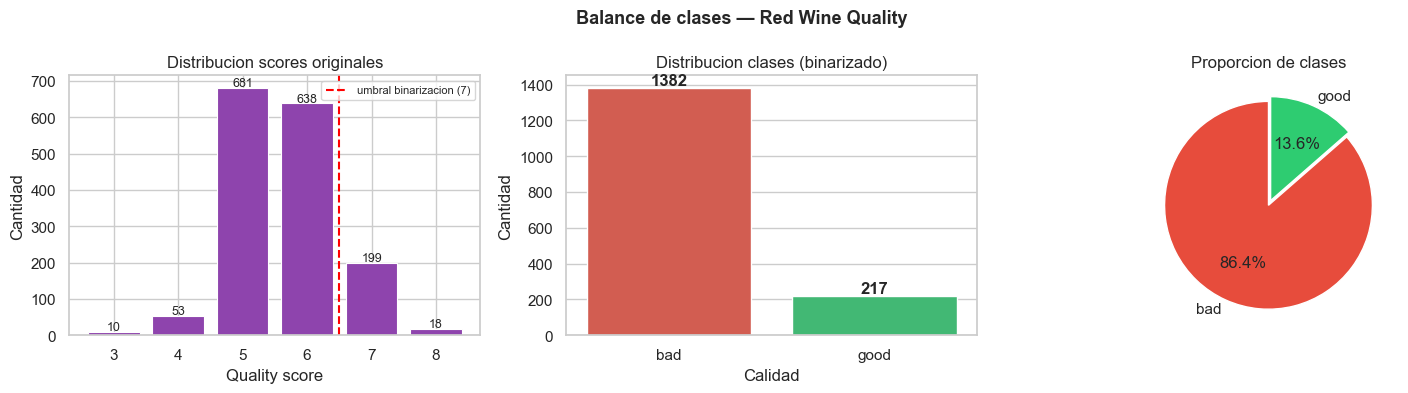

In [8]:
class_counts = df['quality_str'].value_counts()
class_pct    = df['quality_str'].value_counts(normalize=True) * 100

print('=== Balance de clases (binarizado) ===')
for cls in class_counts.index:
    print(f'  {cls:6s}: {class_counts[cls]:5d} muestras ({class_pct[cls]:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette = {'bad': '#e74c3c', 'good': '#2ecc71'}

score_counts = y_raw.value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values, color='#8e44ad', edgecolor='white', linewidth=0.8)
axes[0].axvline(x=6.5, color='red', linestyle='--', linewidth=1.5, label='umbral binarizacion (7)')
axes[0].set_title('Distribucion scores originales')
axes[0].set_xlabel('Quality score')
axes[0].set_ylabel('Cantidad')
axes[0].legend(fontsize=8)
for k, v in score_counts.items():
    axes[0].text(k, v + 5, str(v), ha='center', fontsize=9)

sns.countplot(data=df, x='quality_str', hue='quality_str', ax=axes[1], order=['bad', 'good'], palette=palette)
axes[1].set_title('Distribucion clases (binarizado)')
axes[1].set_xlabel('Calidad')
axes[1].set_ylabel('Cantidad')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[2].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90, explode=(0, 0.05))
axes[2].set_title('Proporcion de clases')

plt.suptitle('Balance de clases — Red Wine Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Estadísticas descriptivas

In [9]:
desc = X.describe().T
desc['cv'] = (desc['std'] / desc['mean']).round(3)
desc = desc[['mean', 'std', 'cv', 'min', '25%', '50%', '75%', 'max']]
desc.columns = ['Media', 'Std', 'CV', 'Min', 'Q1', 'Mediana', 'Q3', 'Max']

print('=== Estadisticas descriptivas (features) ===')
desc.round(4)

=== Estadisticas descriptivas (features) ===


,Media,Std,CV,Min,Q1,Mediana,Q3,Max
fixed acidity,8.3196,1.7411,0.209,4.6000,7.1000,7.9000,9.2000,15.9000
volatile acidity,0.5278,0.1791,0.339,0.1200,0.3900,0.5200,0.6400,1.5800
citric acid,0.2710,0.1948,0.719,0.0000,0.0900,0.2600,0.4200,1.0000
residual sugar,2.5388,1.4099,0.555,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,0.0875,0.0471,0.538,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,15.8749,10.4602,0.659,1.0000,7.0000,14.0000,21.0000,72.0000
total sulfur dioxide,46.4678,32.8953,0.708,6.0000,22.0000,38.0000,62.0000,289.0000
density,0.9967,0.0019,0.002,0.9901,0.9956,0.9968,0.9978,1.0037
pH,3.3111,0.1544,0.047,2.7400,3.2100,3.3100,3.4000,4.0100
sulphates,0.6581,0.1695,0.258,0.3300,0.5500,0.6200,0.7300,2.0000


### Distribución de features por clase

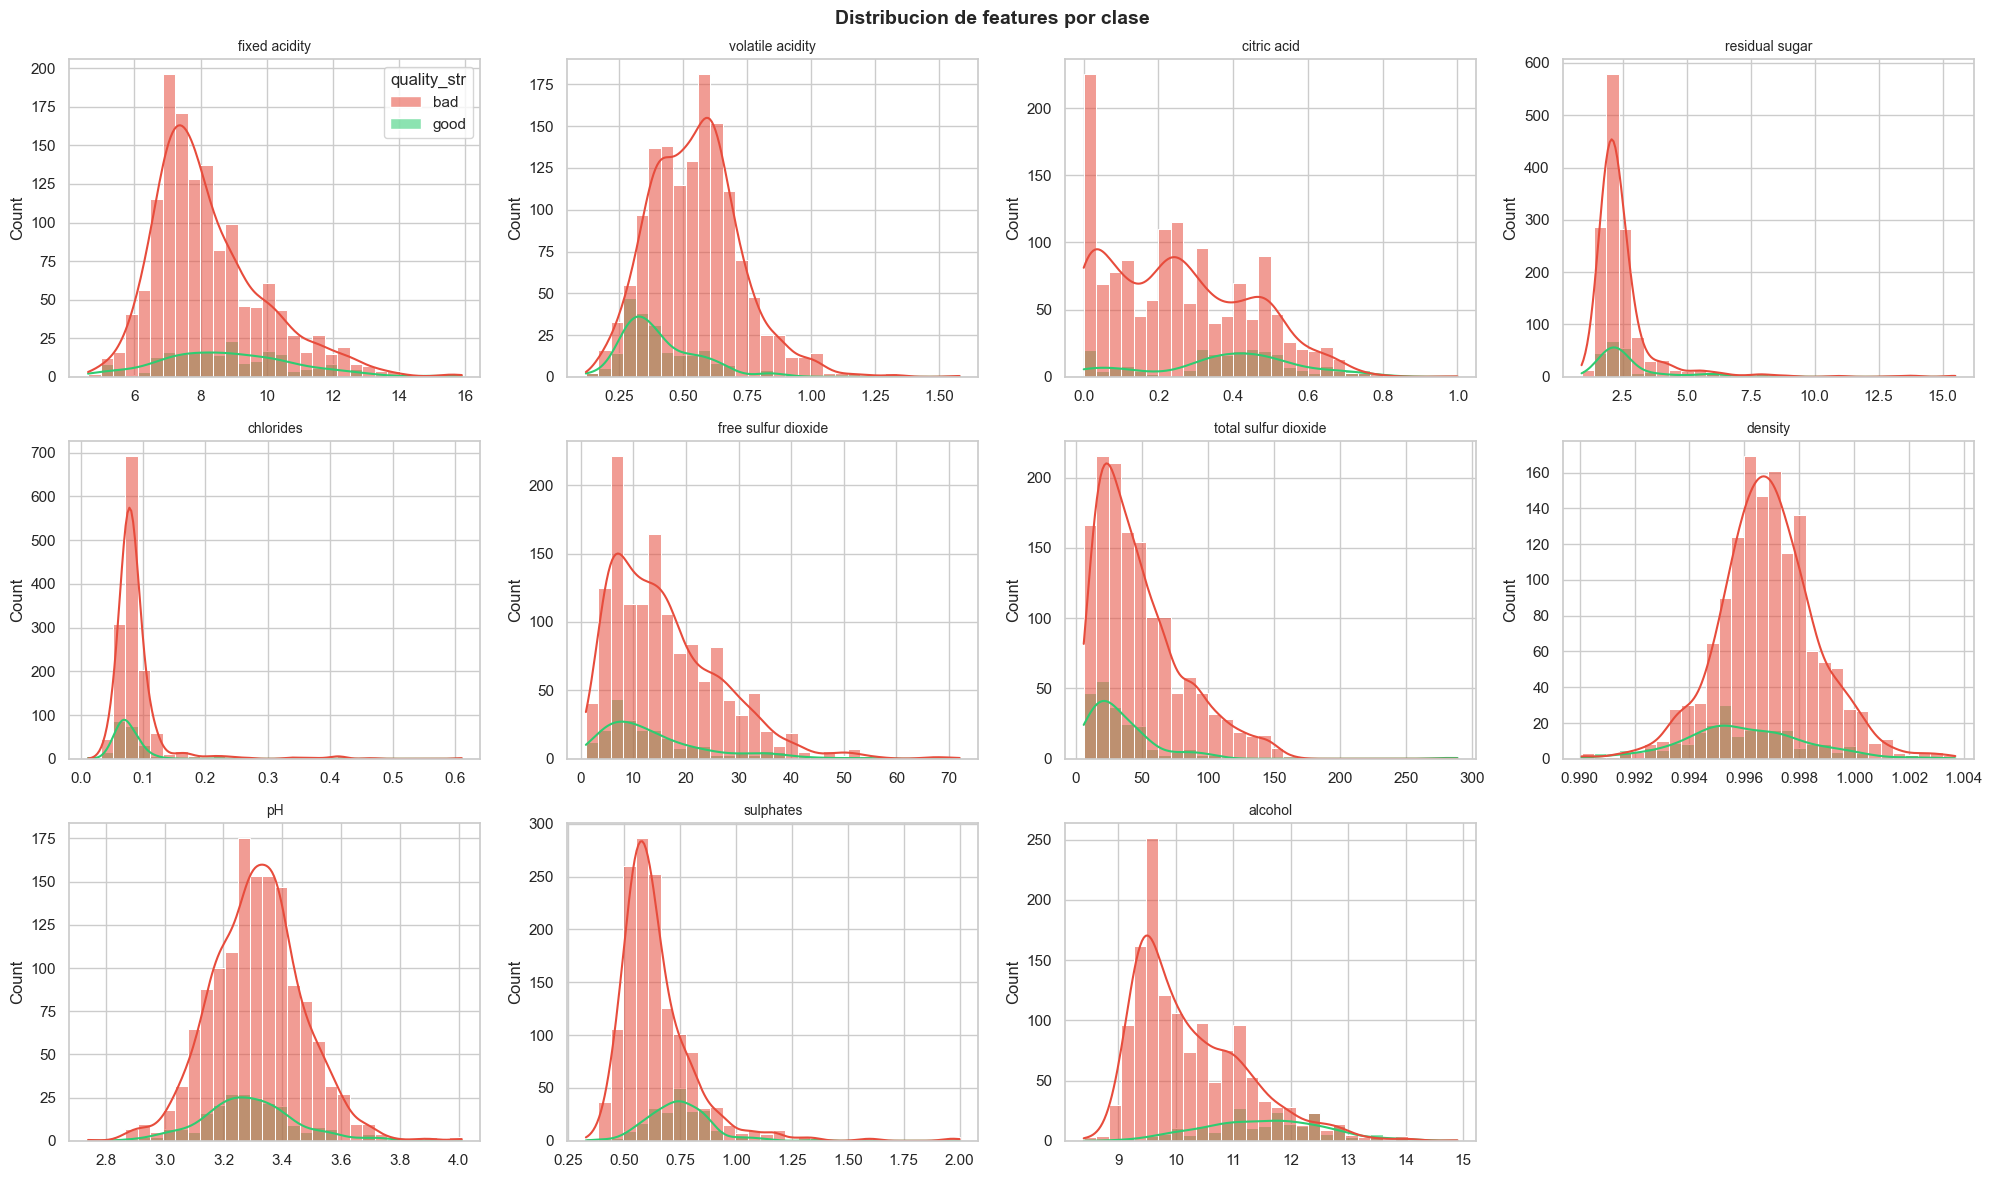

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    sns.histplot(data=df, x=feat, hue='quality_str',
                 ax=axes[i], kde=True, palette=palette, alpha=0.55, bins=30)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    if i != 0:
        axes[i].get_legend().remove()

axes[-1].set_visible(False)
plt.suptitle('Distribucion de features por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Boxplots por clase

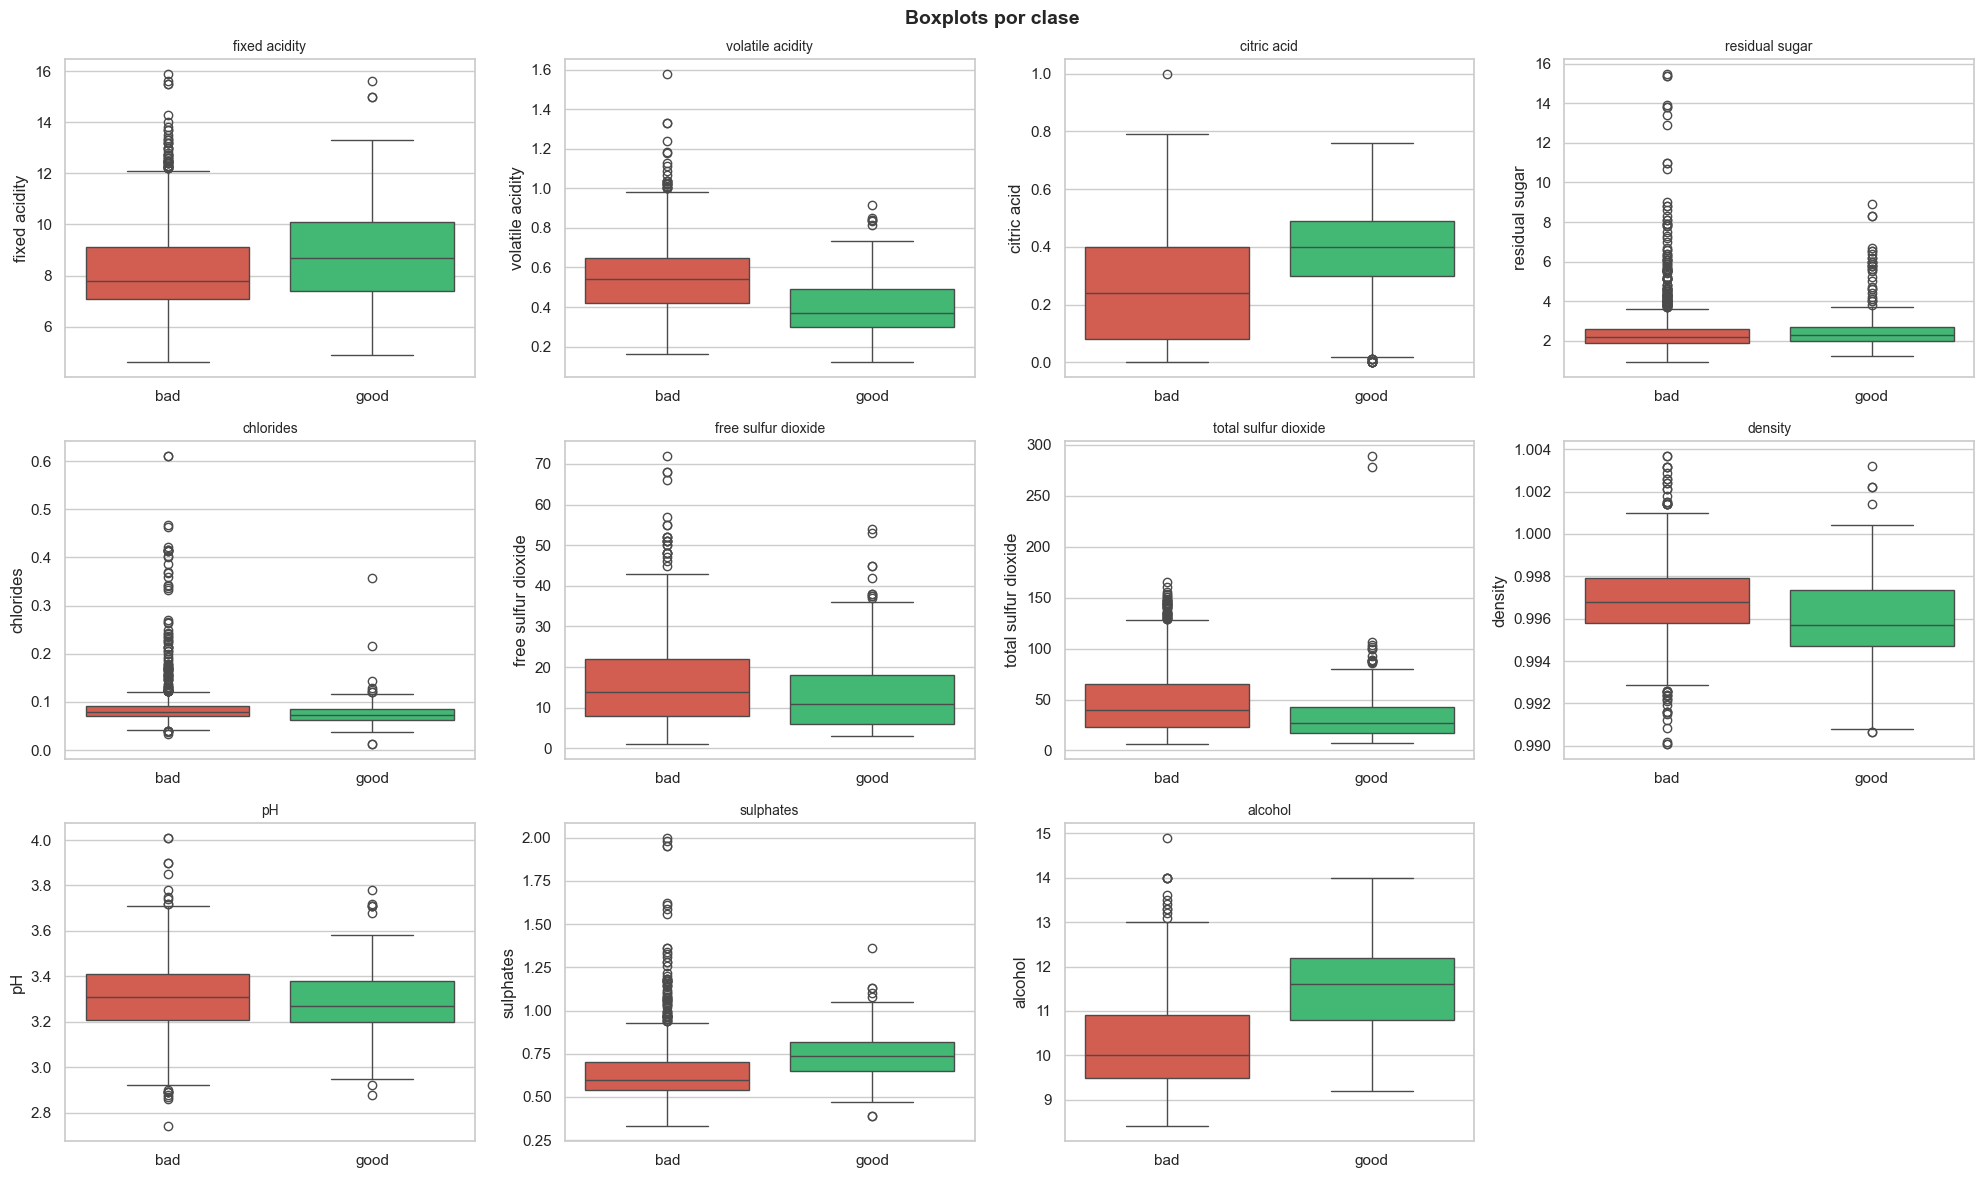

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    sns.boxplot(data=df, x='quality_str', y=feat, hue='quality_str',
                ax=axes[i], palette=palette, order=['bad', 'good'])
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Boxplots por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Matriz de correlación

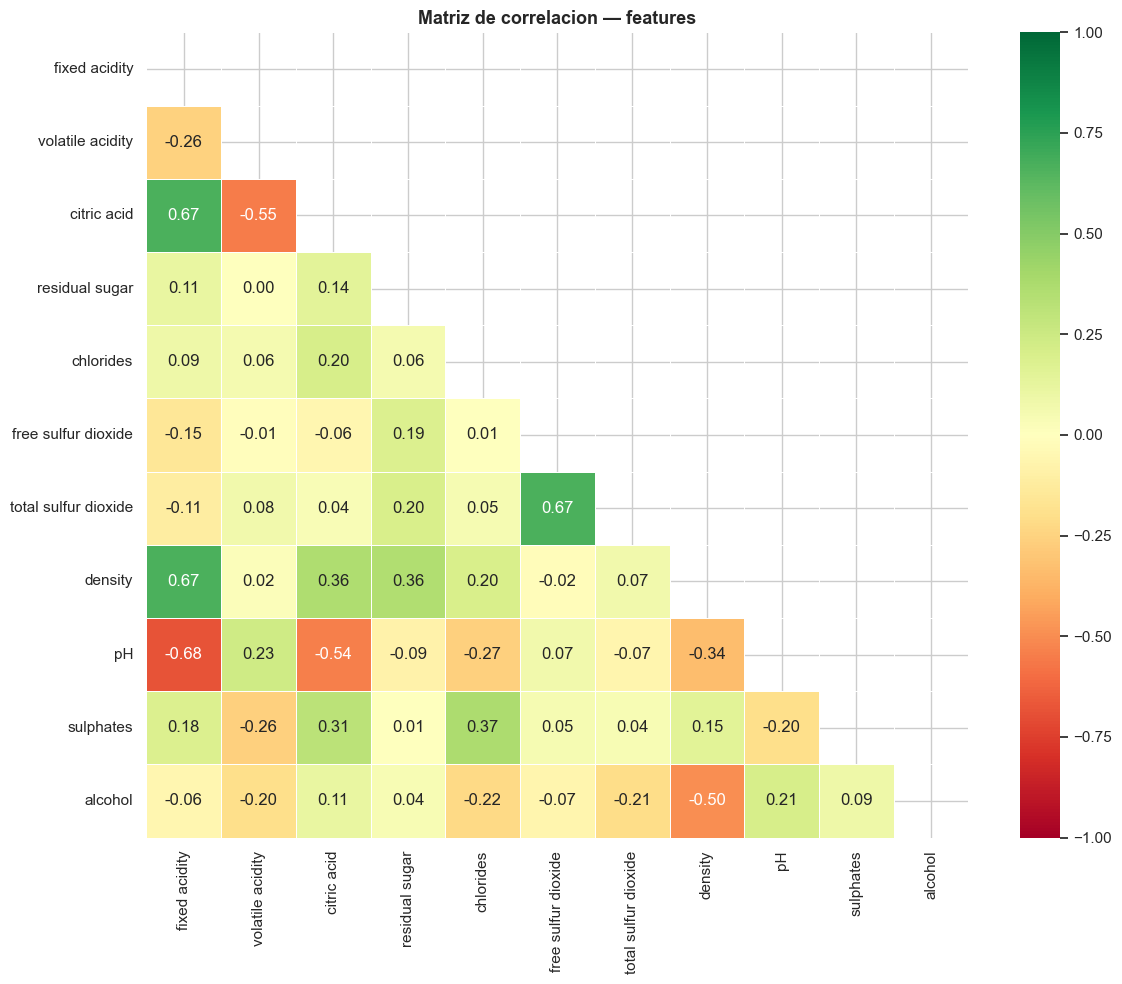

Pares con |r| > 0.70:


In [12]:
corr_matrix = X.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5)
ax.set_title('Matriz de correlacion — features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

print('Pares con |r| > 0.70:')
for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f'  {a:30s} <-> {b:30s}  r = {r}')

### Correlación de cada feature con el score de calidad

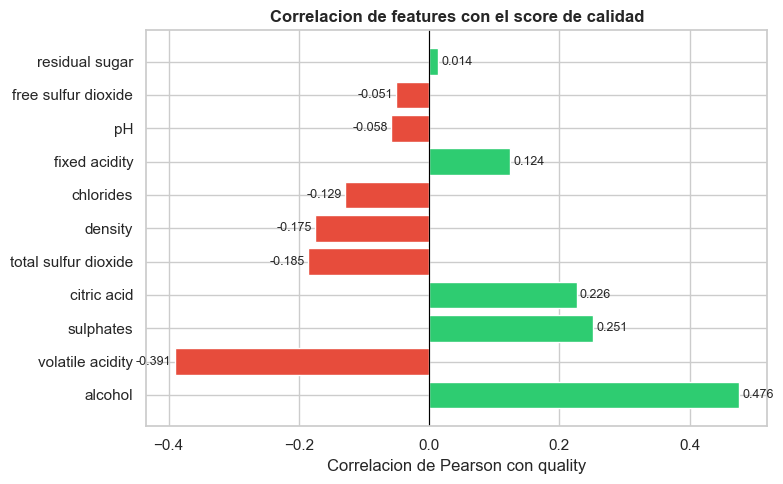

In [13]:
corr_with_target = X.corrwith(y_raw).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlacion de Pearson con quality')
ax.set_title('Correlacion de features con el score de calidad', fontsize=12, fontweight='bold')
for feat, val in corr_with_target.items():
    ax.text(val + (0.005 if val >= 0 else -0.005), list(corr_with_target.index).index(feat),
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

### Detección de outliers (IQR)

=== Outliers por feature (criterio IQR) ===
residual sugar          155
chlorides               112
sulphates                59
total sulfur dioxide     55
fixed acidity            49
density                  45
pH                       35
free sulfur dioxide      30
volatile acidity         19
alcohol                  13
citric acid               1

Muestras con al menos 1 outlier: 405 / 1599


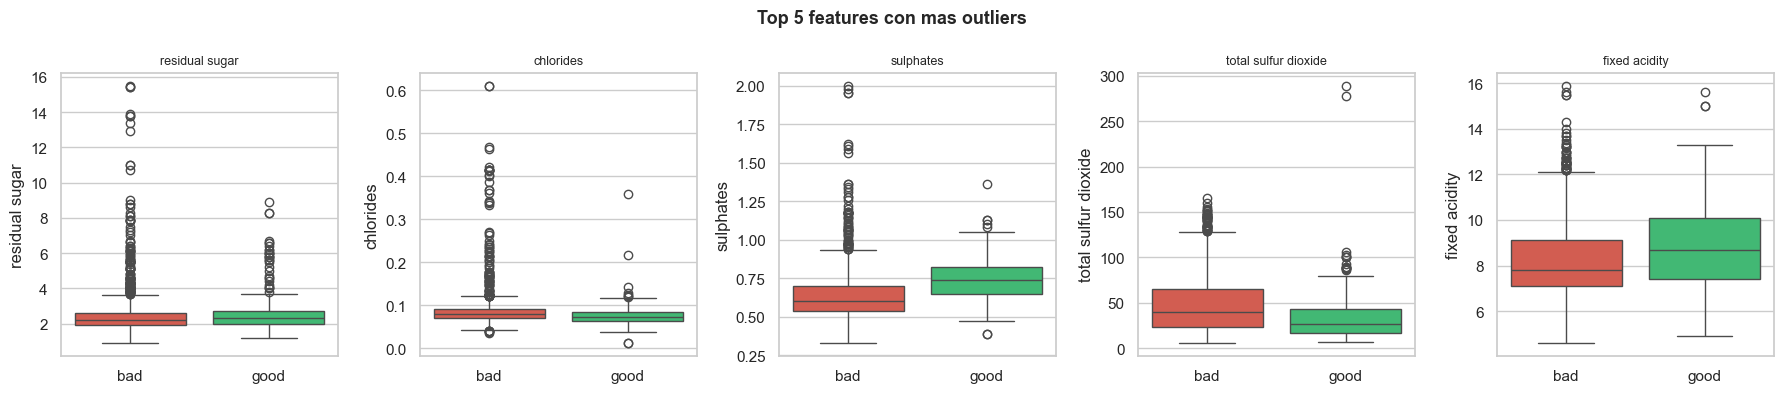

In [14]:
Q1  = X.quantile(0.25)
Q3  = X.quantile(0.75)
IQR = Q3 - Q1

outlier_mask   = (X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))
outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print('=== Outliers por feature (criterio IQR) ===')
print(outlier_counts[outlier_counts > 0].to_string())
print(f'\nMuestras con al menos 1 outlier: {outlier_mask.any(axis=1).sum()} / {len(df)}')

top5 = outlier_counts.head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, feat in enumerate(top5):
    sns.boxplot(data=df, y=feat, x='quality_str', hue='quality_str',
                ax=axes[i], palette=palette, order=['bad', 'good'])
    axes[i].set_title(feat[:20], fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Top 5 features con mas outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Proyección PCA — separabilidad visual

/opt/homebrew/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/homebrew/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/homebrew/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


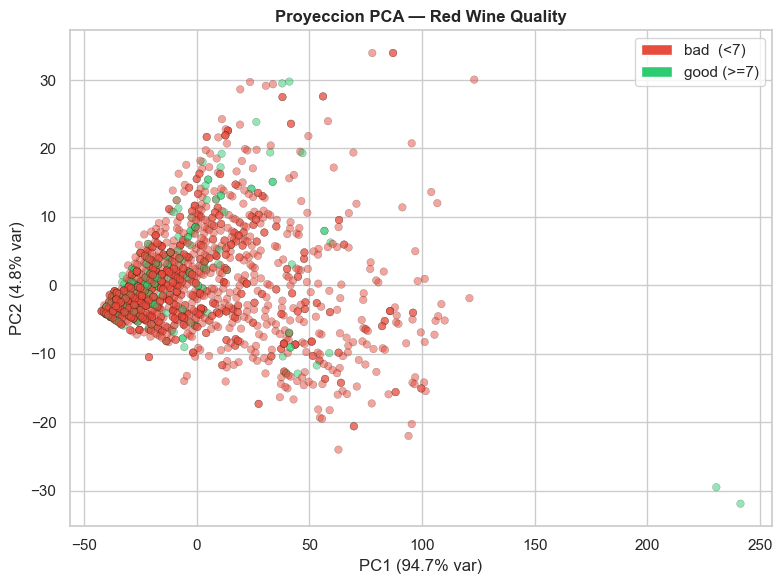

Varianza explicada acumulada: 99.49%


In [15]:
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

colors = y.map({0: '#e74c3c', 1: '#2ecc71'})
legend_elements = [Patch(facecolor='#e74c3c', label='bad  (<7)'),
                   Patch(facecolor='#2ecc71', label='good (>=7)')]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.5,
           edgecolors='k', linewidths=0.2, s=30)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Proyeccion PCA — Red Wine Quality', fontsize=12, fontweight='bold')
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

print(f'Varianza explicada acumulada: {sum(pca.explained_variance_ratio_)*100:.2f}%')

### Valores faltantes

In [16]:
missing = X.isna().sum()
print('=== Valores faltantes por feature ===')
if missing.sum() == 0:
    print('  No se encontraron valores faltantes. OK')
else:
    print(missing[missing > 0])

=== Valores faltantes por feature ===
  No se encontraron valores faltantes. OK


---
## 2c–2d. Preprocesamiento de Datos

Los kernels RBF y k-NN de Label Propagation/Spreading dependen de **distancias euclidianas**. Las 11 features del dataset tienen rangos muy distintos (p.ej. `total sulfur dioxide` llega a ~289 mientras `density` ronda 0.99), lo que distorsionaría la matriz de afinidad W sin estandarización.

Pasos aplicados:
1. **Variables categóricas**: ninguna — no se requiere encoding.
2. **Outliers**: se conservan; los métodos de propagación son robustos a ruido moderado y eliminarlos reduciría muestras valiosas de la clase minoritaria (`good`).
3. **Estandarización z-score** (`StandardScaler`): media 0, std 1 en cada feature.
4. **Construcción del conjunto semi-supervisado**: 20% etiquetado / 80% con `y = -1`.

### Verificación de variables categóricas

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

cat_cols = X.select_dtypes(include='object').columns.tolist()
if len(cat_cols) == 0:
    print('No existen variables categoricas. One-hot encoding no requerido. OK')
else:
    print(f'Variables categoricas encontradas: {cat_cols}')

No existen variables categoricas. One-hot encoding no requerido. OK


### Decisión sobre outliers

In [18]:
outliers_por_clase = pd.DataFrame({
    'total_outliers': outlier_mask.sum(axis=1),
    'clase': df['quality_str']
})

print('Outliers por clase:')
print(outliers_por_clase.groupby('clase')['total_outliers'].describe().round(2))
print()
print('Muestras de clase "good" con outliers:',
      outlier_mask.any(axis=1)[y == 1].sum(), '/', (y == 1).sum())
print('Decision: se conservan los outliers para no perder muestras de la clase minoritaria.')

Outliers por clase:
        count  mean   std  min  25%  50%  75%  max
clase                                             
bad    1382.0  0.35  0.72  0.0  0.0  0.0  0.0  4.0
good    217.0  0.43  0.72  0.0  0.0  0.0  1.0  3.0

Muestras de clase "good" con outliers: 70 / 217
Decision: se conservan los outliers para no perder muestras de la clase minoritaria.


### Estandarización z-score

In [19]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

stats_post = X_scaled_df.describe().T[['mean', 'std', 'min', 'max']]
stats_post.columns = ['Media', 'Std', 'Min', 'Max']
print('=== Verificacion post-estandarizacion ===')
print(stats_post.round(4).to_string())
print(f'\nMedia global : {X_scaled_df.values.mean():.6f}  (esperado ~0)')
print(f'Std global   : {X_scaled_df.values.std():.6f}   (esperado ~1)')

=== Verificacion post-estandarizacion ===
                      Media     Std     Min      Max
fixed acidity           0.0  1.0003 -2.1370   4.3551
volatile acidity        0.0  1.0003 -2.2783   5.8780
citric acid            -0.0  1.0003 -1.3915   3.7436
residual sugar         -0.0  1.0003 -1.1627   9.1957
chlorides               0.0  1.0003 -1.6039  11.1270
free sulfur dioxide    -0.0  1.0003 -1.4225   5.3673
total sulfur dioxide    0.0  1.0003 -1.2306   7.3752
density                -0.0  1.0003 -3.5387   3.6801
pH                      0.0  1.0003 -3.7004   4.5283
sulphates               0.0  1.0003 -1.9365   7.9187
alcohol                 0.0  1.0003 -1.8989   4.2025

Media global : -0.000000  (esperado ~0)
Std global   : 1.000000   (esperado ~1)


### Comparación antes vs. después de estandarizar

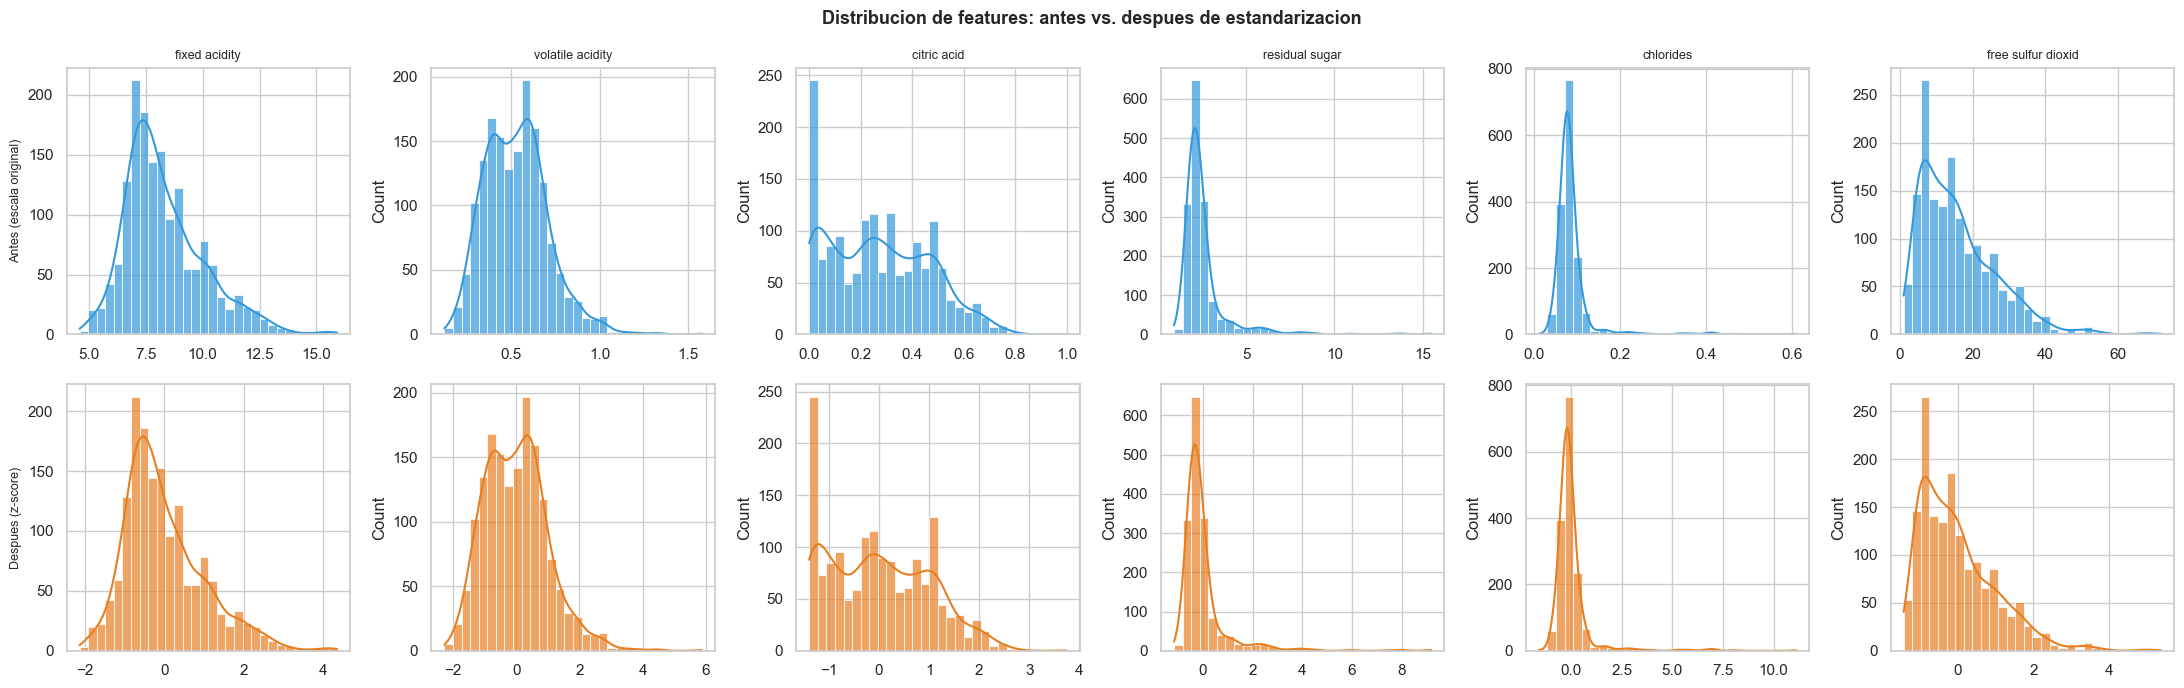

In [20]:
sample_feats = feature_cols[:6]

fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for i, feat in enumerate(sample_feats):
    sns.histplot(X[feat], ax=axes[0, i], kde=True, color='#3498db', bins=30, alpha=0.7)
    axes[0, i].set_title(feat[:18], fontsize=9)
    axes[0, i].set_xlabel('')
    if i == 0:
        axes[0, i].set_ylabel('Antes (escala original)', fontsize=9)

    sns.histplot(X_scaled_df[feat], ax=axes[1, i], kde=True, color='#e67e22', bins=30, alpha=0.7)
    axes[1, i].set_xlabel('')
    if i == 0:
        axes[1, i].set_ylabel('Despues (z-score)', fontsize=9)

plt.suptitle('Distribucion de features: antes vs. despues de estandarizacion',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Impacto en distancias euclidianas

/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


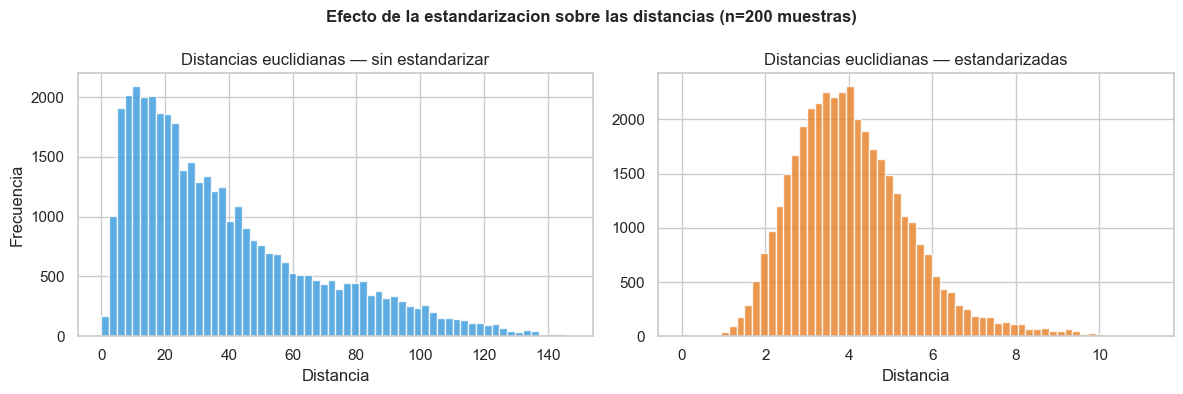

Sin estandarizar — media: 38.28, rango: [0.00, 146.91]
Estandarizadas   — media: 4.07,  rango: [0.00, 11.22]


In [21]:
from sklearn.metrics import pairwise_distances

rng = np.random.default_rng(42)
idx = rng.choice(len(X), size=200, replace=False)

dist_before = pairwise_distances(X.values[idx], metric='euclidean').flatten()
dist_after  = pairwise_distances(X_scaled[idx],  metric='euclidean').flatten()
dist_before = dist_before[dist_before > 0]
dist_after  = dist_after[dist_after  > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dist_before, bins=60, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].set_title('Distancias euclidianas — sin estandarizar')
axes[0].set_xlabel('Distancia')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(dist_after, bins=60, color='#e67e22', alpha=0.8, edgecolor='white')
axes[1].set_title('Distancias euclidianas — estandarizadas')
axes[1].set_xlabel('Distancia')

plt.suptitle('Efecto de la estandarizacion sobre las distancias (n=200 muestras)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Sin estandarizar — media: {dist_before.mean():.2f}, rango: [{dist_before.min():.2f}, {dist_before.max():.2f}]')
print(f'Estandarizadas   — media: {dist_after.mean():.2f},  rango: [{dist_after.min():.2f}, {dist_after.max():.2f}]')

### Construcción del conjunto semi-supervisado

Label Propagation y Label Spreading requieren que la mayoría de muestras tengan `y = -1` (no etiquetadas). Se simula un escenario donde solo el **20% de las muestras tienen etiqueta conocida**, con estratificación para mantener el balance de clases.

In [22]:
LABELED_RATIO = 0.20
RANDOM_STATE  = 42

X_lab, X_unlab, y_lab, y_unlab = train_test_split(
    X_scaled, y.values,
    test_size=1 - LABELED_RATIO,
    stratify=y.values,
    random_state=RANDOM_STATE
)

y_semi = np.concatenate([y_lab, np.full(len(y_unlab), -1)])
X_semi = np.vstack([X_lab, X_unlab])

print('=== Configuracion semi-supervisada ===')
print(f'Total muestras       : {len(y_semi)}')
print(f'Etiquetadas  (20%)   : {(y_semi != -1).sum()} '
      f'[{(y_semi[y_semi != -1] == 0).sum()} bad, '
      f'{(y_semi[y_semi != -1] == 1).sum()} good]')
print(f'No etiquetadas (80%) : {(y_semi == -1).sum()}')

=== Configuracion semi-supervisada ===
Total muestras       : 1599
Etiquetadas  (20%)   : 319 [276 bad, 43 good]
No etiquetadas (80%) : 1280


/opt/homebrew/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/homebrew/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/homebrew/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/homebrew/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/homebrew/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/homebrew/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


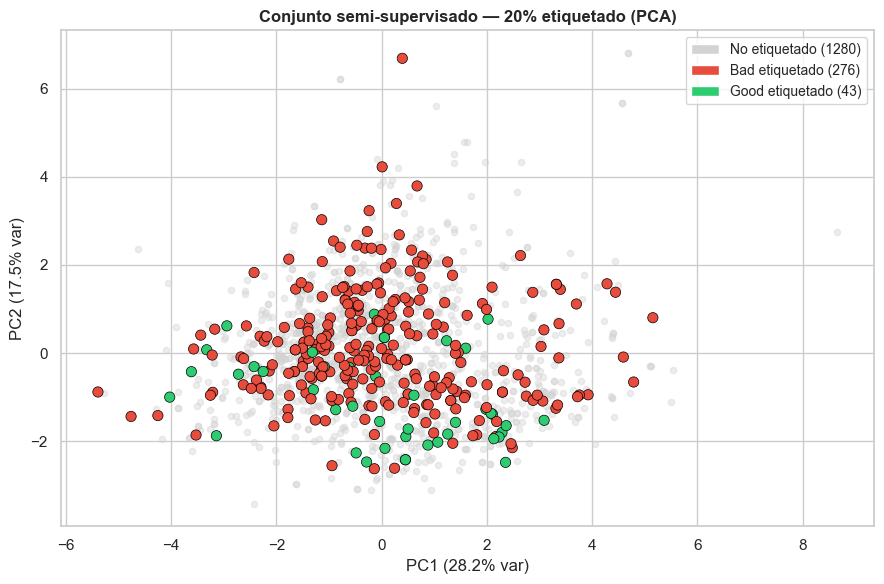

In [23]:
pca2 = PCA(n_components=2, random_state=42)
X_semi_pca = pca2.fit_transform(X_semi)

labeled_mask   = y_semi != -1
unlabeled_mask = y_semi == -1

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X_semi_pca[unlabeled_mask, 0], X_semi_pca[unlabeled_mask, 1],
           c='lightgray', alpha=0.4, s=20, label='No etiquetado', zorder=1)

colors_lab = np.where(y_semi[labeled_mask] == 0, '#e74c3c', '#2ecc71')
ax.scatter(X_semi_pca[labeled_mask, 0], X_semi_pca[labeled_mask, 1],
           c=colors_lab, s=55, edgecolors='black', linewidths=0.5, zorder=2)

legend_elements = [
    Patch(facecolor='lightgray', label=f'No etiquetado ({unlabeled_mask.sum()})'),
    Patch(facecolor='#e74c3c',   label=f'Bad etiquetado ({(y_semi[labeled_mask]==0).sum()})'),
    Patch(facecolor='#2ecc71',   label=f'Good etiquetado ({(y_semi[labeled_mask]==1).sum()})')
]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Conjunto semi-supervisado — 20% etiquetado (PCA)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Resumen final del dataset preprocesado

In [24]:
print('=' * 52)
print('  RESUMEN — Dataset preprocesado (Fase 2)')
print('=' * 52)
print(f'  Dataset            : Red Wine Quality (UCI)')
print(f'  Muestras totales   : {X_semi.shape[0]}')
print(f'  Features           : {X_semi.shape[1]} (todas numericas)')
print(f'  Clases             : 2  (0=bad <7, 1=good >=7)')
print(f'  Valores faltantes  : 0')
print(f'  Encoding           : No requerido')
print(f'  Outliers           : conservados (clase minoritaria)')
print(f'  Escalado           : StandardScaler (z-score)')
print(f'  Etiquetadas  (20%) : {(y_semi != -1).sum()}')
print(f'  No etiquetadas(80%): {(y_semi == -1).sum()}')
print('=' * 52)
print('  Listo para Label Propagation / Label Spreading OK')
print('=' * 52)

  RESUMEN — Dataset preprocesado (Fase 2)
  Dataset            : Red Wine Quality (UCI)
  Muestras totales   : 1599
  Features           : 11 (todas numericas)
  Clases             : 2  (0=bad <7, 1=good >=7)
  Valores faltantes  : 0
  Encoding           : No requerido
  Outliers           : conservados (clase minoritaria)
  Escalado           : StandardScaler (z-score)
  Etiquetadas  (20%) : 319
  No etiquetadas(80%): 1280
  Listo para Label Propagation / Label Spreading OK


---

## Fase 3 — Diseño Experimental

### 3a. Separación de datos y evaluación de porcentajes
Para evaluar el impacto de la cantidad de datos etiquetados en el rendimiento de los modelos, realizaremos primero una partición de los datos en un conjunto de entrenamiento (80%) y uno de prueba (20%).
El conjunto de prueba se mantendrá intacto para medir el desempeño real. Sobre el conjunto de entrenamiento, evaluaremos distintos porcentajes de datos etiquetados (5%, 10%, 20%, 30%, 50%), ocultando las etiquetas del resto.

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

BASE_TEST_SIZE = 0.20
RANDOM_STATE = 42

# 1. Separación base: Train (80%) y Test (20%)
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_scaled, y.values,
    test_size=BASE_TEST_SIZE,
    stratify=y.values,
    random_state=RANDOM_STATE
)

print(f'Conjunto de entrenamiento total: {X_train_base.shape[0]} muestras')
print(f'Conjunto de prueba (Hold-out test): {X_test_base.shape[0]} muestras')

# Definir porcentajes de datos etiquetados a evaluar
labeled_percentages = [0.05, 0.10, 0.20, 0.30, 0.50]
# Función para generar el conjunto de entrenamiento semi-supervisado a partir de la base de train
def create_semi_supervised_train_set(X, y_data, labeled_ratio, random_state=42):
    X_lab, X_unlab, y_lab, y_unlab = train_test_split(
        X, y_data,
        train_size=labeled_ratio,
        stratify=y_data,
        random_state=random_state
    )
    
    # Reconstruimos los datos combinando etiquetados y no etiquetados (-1)
    X_semi = np.vstack([X_lab, X_unlab])
    y_semi_local = np.concatenate([y_lab, np.full(len(y_unlab), -1)])
    
    return X_semi, y_semi_local, X_lab, y_lab

print(f'\nPorcentajes a iterar: {[f"{p*100}%" for p in labeled_percentages]}')

Conjunto de entrenamiento total: 1279 muestras
Conjunto de prueba (Hold-out test): 320 muestras

Porcentajes a iterar: ['5.0%', '10.0%', '20.0%', '30.0%', '50.0%']


### 3b. Definición y comparación de modelos (Supervisado vs Semi-supervisado)
Evaluaremos tres modelos para observar y comparar el desempeño:
1. **Supervisado (SVC)**: Entrenado *únicamente* con la pequeña porción de datos etiquetados.
2. **Label Propagation**: Modelo semi-supervisado basado en grafos empleando k-NN y Laplacianos.
3. **Label Spreading**: Variante de Label Propagation que incluye regularización.

Iteramos sobre cada porcentaje definido y registramos el accuracy evaluado en el **conjunto de prueba intacto**, para asegurar una comparación justa del desempeño frente a datos completamente nuevos.

In [26]:
import warnings
import pandas as pd
from sklearn.svm import SVC
from sklearn.semi_supervised import LabelPropagation, LabelSpreading

warnings.filterwarnings('ignore', category=RuntimeWarning)

pd.options.display.float_format = '{:.4f}'.format

# Diccionarios para almacenar resultados de precisión (Accuracy)
results = {
    'Supervised (SVC)': [],
    'Label Propagation': [],
    'Label Spreading': []
}

print('=== Entrenando modelos iterativamente ===')

for ratio in labeled_percentages:
    # 1. Generar subconjunto etiquetado (para supervisado) y con faltantes (para semi-supervisado)
    X_s, y_s, X_labeled, y_labeled = create_semi_supervised_train_set(
        X_train_base, y_train_base, ratio, random_state=RANDOM_STATE
    )
    
    # 2. Modelo Supervisado Baseline
    # Usamos solo los datos que tienen etiqueta
    clf_sup = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
    clf_sup.fit(X_labeled, y_labeled)
    acc_sup = accuracy_score(y_test_base, clf_sup.predict(X_test_base))
    
    # 3. Modelo Label Propagation
    # Se entrena con todos los datos de 'train', pero solo un % tiene la etiqueta correcta, los demas tienen -1
    clf_lp = LabelPropagation(kernel='rbf')
    clf_lp.fit(X_s, y_s)
    acc_lp = accuracy_score(y_test_base, clf_lp.predict(X_test_base))
    
    # 4. Modelo Label Spreading
    clf_ls = LabelSpreading(kernel='rbf', alpha=0.2)
    clf_ls.fit(X_s, y_s)
    acc_ls = accuracy_score(y_test_base, clf_ls.predict(X_test_base))
    
    # Registrar resultados
    results['Supervised (SVC)'].append(acc_sup)
    results['Label Propagation'].append(acc_lp)
    results['Label Spreading'].append(acc_ls)
    
    print(f'-> Ratio {ratio*100:2.0f}% | Labeled samples: {len(y_labeled):3d} '
          f'| ACC -> SVC: {acc_sup:.4f} | LP: {acc_lp:.4f} | LS: {acc_ls:.4f}')

# Mostrar resultados en DataFrame
results_df = pd.DataFrame(results, index=[f"{int(r*100)}%" for r in labeled_percentages])
print('\n=== Resultados Finales (Test Accuracy) ===')
results_df

=== Entrenando modelos iterativamente ===


/opt/homebrew/lib/python3.10/site-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(


-> Ratio  5% | Labeled samples:  63 | ACC -> SVC: 0.8656 | LP: 0.8094 | LS: 0.8281
-> Ratio 10% | Labeled samples: 127 | ACC -> SVC: 0.8656 | LP: 0.8250 | LS: 0.8438


/opt/homebrew/lib/python3.10/site-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(


-> Ratio 20% | Labeled samples: 255 | ACC -> SVC: 0.8781 | LP: 0.8531 | LS: 0.8688
-> Ratio 30% | Labeled samples: 383 | ACC -> SVC: 0.9000 | LP: 0.8500 | LS: 0.8906
-> Ratio 50% | Labeled samples: 639 | ACC -> SVC: 0.9062 | LP: 0.8688 | LS: 0.9000

=== Resultados Finales (Test Accuracy) ===


/opt/homebrew/lib/python3.10/site-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(


,Supervised (SVC),Label Propagation,Label Spreading
5%,0.8656,0.8094,0.8281
10%,0.8656,0.8250,0.8438
20%,0.8781,0.8531,0.8688
30%,0.9000,0.8500,0.8906
50%,0.9062,0.8688,0.9000


### 3c. Visualización del desempeño y comparación
A continuación graficaremos los resultados para evidenciar el incremento del accuracy respecto a la cantidad de datos etiquetados disponibles. Analíticamente comparamos los modelos semi-supervisados basados en grafos (propagación de etiquetas y laplacianos) contra el modelo supervisado estándar.

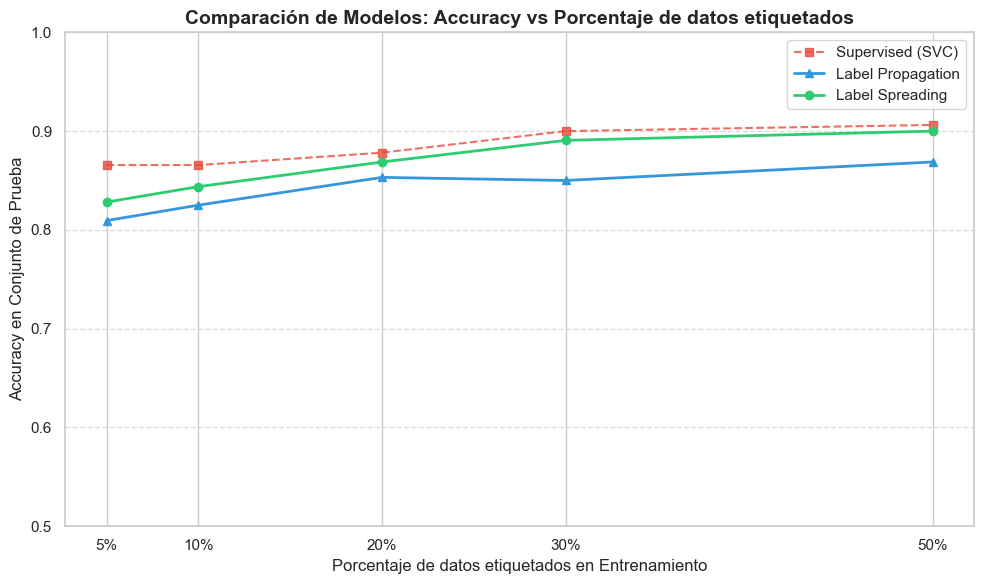

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for model_name in results.keys():
    if 'SVC' in model_name:
        plt.plot(labeled_percentages, results[model_name], marker='s', linestyle='--', label=model_name, color='#e74c3c', alpha=0.8)
    elif 'Spreading' in model_name:
        plt.plot(labeled_percentages, results[model_name], marker='o', linewidth=2, label=model_name, color='#2ecc71')
    else:
        plt.plot(labeled_percentages, results[model_name], marker='^', linewidth=2, label=model_name, color='#3498db')

plt.title('Comparación de Modelos: Accuracy vs Porcentaje de datos etiquetados', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje de datos etiquetados en Entrenamiento', fontsize=12)
plt.ylabel('Accuracy en Conjunto de Prueba', fontsize=12)
plt.xticks(labeled_percentages, [f"{int(p*100)}%" for p in labeled_percentages])
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Resumen Comparativo:**
- **Modelo Supervisado (SVC)**: Cuando el porcentaje de datos es muy pequeño (como 5% o 10%), su desempeño puede estancarse o no generalizar muy bien, debido a la deficiencia de datos de entrenamiento para armar correctamente el hiperplano.
- **Modelos Semi-supervisados (Label Propagation y Label Spreading)**: Dado que estos modelos aprovechan la estructura del grafo basada en distancias y vecinos más próximos, mantienen una robustez superior incluso con bajos porcentajes de datos etiquetados. Aprovechan los clústeres intrínsecos del dataset (en este caso de *Red Wine Quality*) para propagar la etiqueta de forma laplaciana.

---

## Fase 4 — Experimentación

### 4a–4c. Variación de hiperparámetros y análisis de sensibilidad

Se fija `labeled_ratio = 0.10` (10% de datos etiquetados, equivalente a 127 muestras
sobre 1279 de entrenamiento) para aislar el efecto de los hiperparámetros del algoritmo.
Se evalúan tres métricas adaptadas al nuevo dataset:
- **Accuracy**: desempeño general
- **F1 weighted**: balance precisión/recall considerando desbalance severo 86/14
- **Recall good**: recall de la clase minoritaria (quality ≥ 7) — la más difícil de capturar

In [28]:
from sklearn.metrics import accuracy_score, f1_score, recall_score
import warnings
warnings.filterwarnings('ignore')

FIXED_RATIO  = 0.10
RANDOM_STATE = 42

X_semi_b, y_semi_b, X_lab_b, y_lab_b = create_semi_supervised_train_set(
    X_train_base, y_train_base, FIXED_RATIO, random_state=RANDOM_STATE
)

def evaluate_model(clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    return {
        'accuracy':    round(accuracy_score(y_test, y_pred), 4),
        'f1':          round(f1_score(y_test, y_pred, average='weighted'), 4),
        'recall_good': round(recall_score(y_test, y_pred, pos_label=1), 4)
    }

print(f'Muestras etiquetadas  : {(y_semi_b != -1).sum()}')
print(f'  -> bad  (0): {(y_semi_b[y_semi_b != -1] == 0).sum()}')
print(f'  -> good (1): {(y_semi_b[y_semi_b != -1] == 1).sum()}')
print(f'Sin etiquetar         : {(y_semi_b == -1).sum()}')
print('Función evaluate_model lista (recall_good = clase minoritaria).')

Muestras etiquetadas  : 127
  -> bad  (0): 110
  -> good (1): 17
Sin etiquetar         : 1152
Función evaluate_model lista (recall_good = clase minoritaria).


### 4b.1 — Variación de n_neighbors (kernel = knn)

In [29]:
n_neighbors_grid = [3, 5, 7, 10, 15]
knn_results = []

for k in n_neighbors_grid:
    lp = LabelPropagation(kernel='knn', n_neighbors=k, max_iter=1000)
    lp.fit(X_semi_b, y_semi_b)
    knn_results.append({'model': 'Label Propagation', 'n_neighbors': k,
                        **evaluate_model(lp, X_test_base, y_test_base)})

    ls = LabelSpreading(kernel='knn', n_neighbors=k, alpha=0.2)
    ls.fit(X_semi_b, y_semi_b)
    knn_results.append({'model': 'Label Spreading', 'n_neighbors': k,
                        **evaluate_model(ls, X_test_base, y_test_base)})

knn_df = pd.DataFrame(knn_results)
print(knn_df.to_string(index=False))

            model  n_neighbors  accuracy     f1  recall_good
Label Propagation            3    0.8750 0.8447       0.1860
  Label Spreading            3    0.8656 0.8380       0.1860
Label Propagation            5    0.8688 0.8255       0.0930
  Label Spreading            5    0.8469 0.8392       0.3256
Label Propagation            7    0.8719 0.8317       0.1163
  Label Spreading            7    0.8656 0.8571       0.3721
Label Propagation           10    0.8719 0.8510       0.2558
  Label Spreading           10    0.8625 0.8547       0.3721
Label Propagation           15    0.8656 0.8033       0.0000
  Label Spreading           15    0.8750 0.8625       0.3488


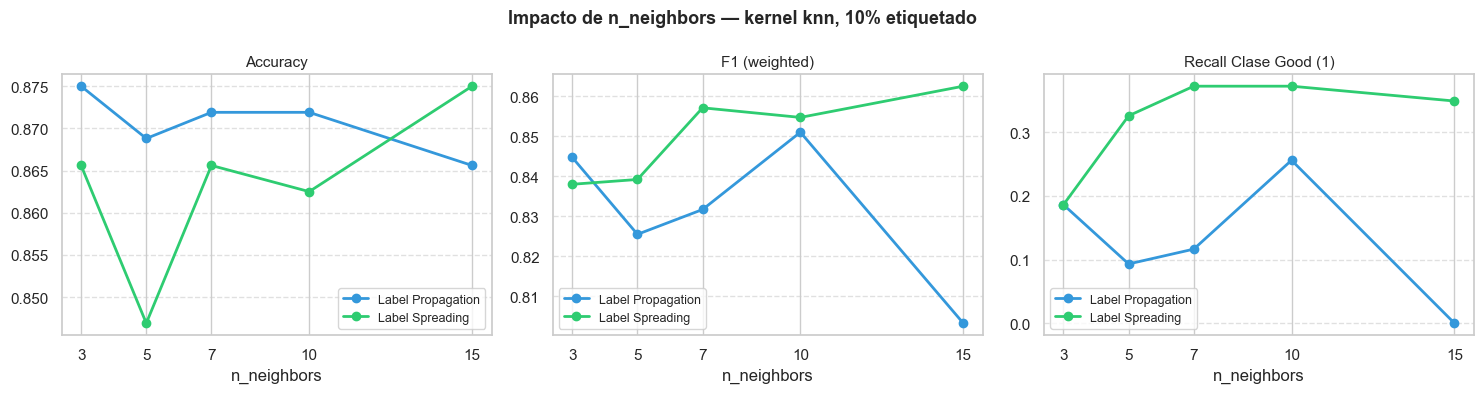

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_to_plot = ['accuracy', 'f1', 'recall_good']
titles          = ['Accuracy', 'F1 (weighted)', 'Recall Clase Good (1)']
colors          = {'Label Propagation': '#3498db', 'Label Spreading': '#2ecc71'}

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    for model in ['Label Propagation', 'Label Spreading']:
        subset = knn_df[knn_df['model'] == model]
        axes[i].plot(subset['n_neighbors'], subset[metric],
                     marker='o', label=model, color=colors[model], linewidth=2)
    axes[i].set_title(title, fontsize=11)
    axes[i].set_xlabel('n_neighbors')
    axes[i].set_xticks(n_neighbors_grid)
    axes[i].legend(fontsize=9)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Impacto de n_neighbors — kernel knn, 10% etiquetado',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
best_lp_k = knn_df[knn_df['model'] == 'Label Propagation'].sort_values('f1', ascending=False).iloc[0]
best_ls_k = knn_df[knn_df['model'] == 'Label Spreading'].sort_values('f1', ascending=False).iloc[0]

print(f"Mejor n_neighbors LP : {int(best_lp_k['n_neighbors'])}  "
      f"(Acc={best_lp_k['accuracy']}, F1={best_lp_k['f1']}, Recall={best_lp_k['recall_good']})")
print(f"Mejor n_neighbors LS : {int(best_ls_k['n_neighbors'])}  "
      f"(Acc={best_ls_k['accuracy']}, F1={best_ls_k['f1']}, Recall={best_ls_k['recall_good']})")

Mejor n_neighbors LP : 10  (Acc=0.8719, F1=0.851, Recall=0.2558)
Mejor n_neighbors LS : 15  (Acc=0.875, F1=0.8625, Recall=0.3488)


### n_neighbors — resultados

| Modelo | Mejor k | Accuracy | F1 | Recall Good |
|---|---|---|---|---|
| Label Propagation | **10** | 0.8719 | 0.8510 | 0.2558 |
| Label Spreading   | **15** | 0.8750 | 0.8625 | 0.3488 |

Label Propagation colapsa en recall a k=15 (0.000): con vecindarios muy grandes,
la clase minoritaria "good" (solo 17 muestras etiquetadas de 127) queda diluida
y sus etiquetas no logran propagarse hacia los nodos sin etiquetar.

Label Spreading es consistentemente más robusto — mejora con k más altos porque
su parámetro alpha amortigua la propagación y evita que la clase mayoritaria
"bad" absorba todo el grafo. Esto lo hace más adecuado para el desbalance 86/14
de este dataset.

El recall_good es la métrica más sensible a n_neighbors: varía entre 0.000 y 0.372
según el modelo y el k elegido, mientras que accuracy apenas se mueve (0.847–0.875).
Esto confirma que accuracy solo no es suficiente para evaluar modelos en datasets
con desbalance severo.

**Valores fijados:** `n_neighbors_LP = 10`, `n_neighbors_LS = 15`

### 4b.2 — Variación de gamma (kernel = rbf)

In [32]:
gamma_grid = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
gamma_results = []

for g in gamma_grid:
    lp = LabelPropagation(kernel='rbf', gamma=g, max_iter=1000)
    lp.fit(X_semi_b, y_semi_b)
    gamma_results.append({'model': 'Label Propagation', 'gamma': g,
                          **evaluate_model(lp, X_test_base, y_test_base)})

    ls = LabelSpreading(kernel='rbf', gamma=g, alpha=0.2)
    ls.fit(X_semi_b, y_semi_b)
    gamma_results.append({'model': 'Label Spreading', 'gamma': g,
                          **evaluate_model(ls, X_test_base, y_test_base)})

gamma_df = pd.DataFrame(gamma_results)
print(gamma_df.to_string(index=False))

best_gamma_lp = gamma_df[gamma_df['model']=='Label Propagation'].sort_values('f1', ascending=False).iloc[0]['gamma']
best_gamma_ls = gamma_df[gamma_df['model']=='Label Spreading'].sort_values('f1', ascending=False).iloc[0]['gamma']
print(f'\nMejor gamma LP: {best_gamma_lp}')
print(f'Mejor gamma LS: {best_gamma_ls}')

            model  gamma  accuracy     f1  recall_good
Label Propagation 0.0010    0.8656 0.8033       0.0000
  Label Spreading 0.0010    0.8656 0.8033       0.0000
Label Propagation 0.0050    0.8656 0.8033       0.0000
  Label Spreading 0.0050    0.8656 0.8033       0.0000
Label Propagation 0.0100    0.8656 0.8033       0.0000
  Label Spreading 0.0100    0.8656 0.8033       0.0000
Label Propagation 0.0500    0.8656 0.8033       0.0000
  Label Spreading 0.0500    0.8656 0.8033       0.0000
Label Propagation 0.1000    0.8656 0.8033       0.0000
  Label Spreading 0.1000    0.8562 0.7986       0.0000
Label Propagation 0.5000    0.8531 0.8023       0.0233
  Label Spreading 0.5000    0.8562 0.8089       0.0465
Label Propagation 1.0000    0.8531 0.8071       0.0465
  Label Spreading 1.0000    0.8688 0.8487       0.2558

Mejor gamma LP: 1.0
Mejor gamma LS: 1.0


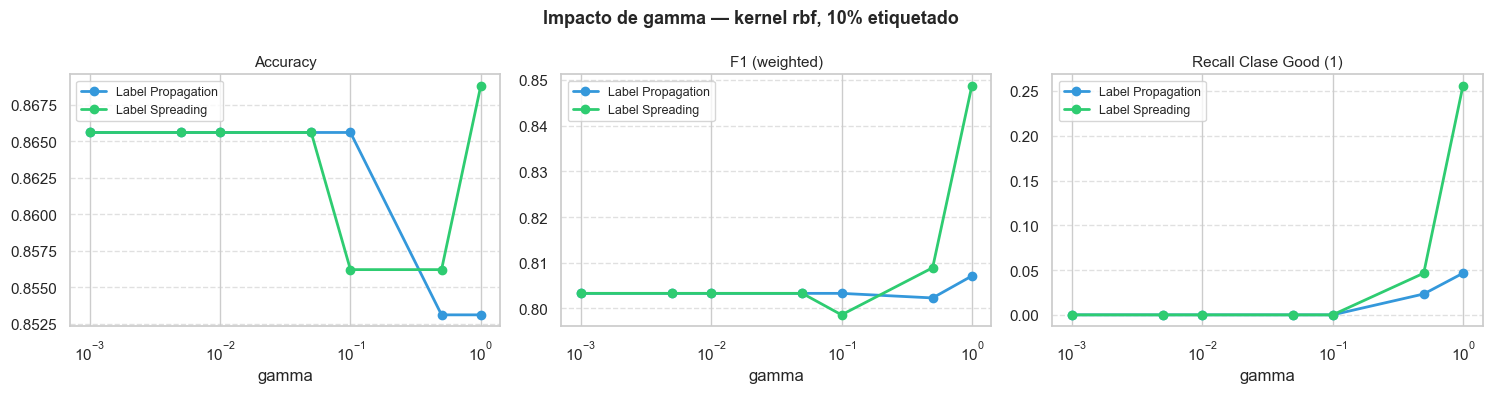

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    for model in ['Label Propagation', 'Label Spreading']:
        subset = gamma_df[gamma_df['model'] == model]
        axes[i].plot(subset['gamma'], subset[metric],
                     marker='o', label=model, color=colors[model], linewidth=2)
    axes[i].set_title(title, fontsize=11)
    axes[i].set_xlabel('gamma')
    axes[i].set_xscale('log')
    axes[i].legend(fontsize=9)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Impacto de gamma — kernel rbf, 10% etiquetado',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4b.3 — Variación de alpha (Label Spreading con mejor gamma)

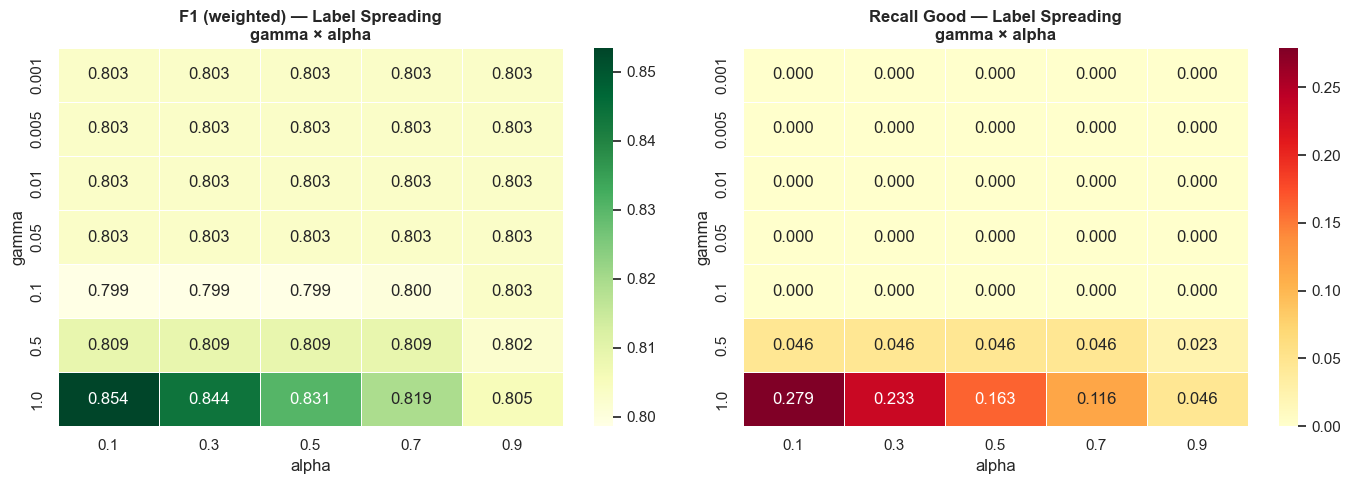

Mejor config LS (rbf): gamma=1.0, alpha=0.1
  Acc=0.8719, F1=0.8535, Recall=0.2791


In [34]:
alpha_grid = [0.1, 0.3, 0.5, 0.7, 0.9]
alpha_results = []

for g in gamma_grid:
    for a in alpha_grid:
        ls = LabelSpreading(kernel='rbf', gamma=g, alpha=a)
        ls.fit(X_semi_b, y_semi_b)
        alpha_results.append({'gamma': g, 'alpha': a,
                              **evaluate_model(ls, X_test_base, y_test_base)})

alpha_df = pd.DataFrame(alpha_results)

pivot_f1     = alpha_df.pivot(index='gamma', columns='alpha', values='f1')
pivot_recall = alpha_df.pivot(index='gamma', columns='alpha', values='recall_good')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='YlGn',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('F1 (weighted) — Label Spreading\ngamma × alpha', fontweight='bold')

sns.heatmap(pivot_recall, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Recall Good — Label Spreading\ngamma × alpha', fontweight='bold')

plt.tight_layout()
plt.show()

best_ls_config = alpha_df.sort_values('f1', ascending=False).iloc[0]
print(f"Mejor config LS (rbf): gamma={best_ls_config['gamma']}, alpha={best_ls_config['alpha']}")
print(f"  Acc={best_ls_config['accuracy']}, F1={best_ls_config['f1']}, Recall={best_ls_config['recall_good']}")

In [35]:
lp_rbf_best = LabelPropagation(kernel='rbf', gamma=best_gamma_lp, max_iter=1000)
lp_rbf_best.fit(X_semi_b, y_semi_b)
m_lp_rbf = evaluate_model(lp_rbf_best, X_test_base, y_test_base)

ls_rbf_best = LabelSpreading(kernel='rbf', gamma=best_ls_config['gamma'], alpha=best_ls_config['alpha'])
ls_rbf_best.fit(X_semi_b, y_semi_b)
m_ls_rbf = evaluate_model(ls_rbf_best, X_test_base, y_test_base)

comparison = pd.DataFrame([
    {'modelo': f'LP — knn (k={int(best_lp_k["n_neighbors"])})',
     **{k: best_lp_k[k] for k in ['accuracy','f1','recall_good']}},
    {'modelo': f'LP — rbf (γ={best_gamma_lp})', **m_lp_rbf},
    {'modelo': f'LS — knn (k={int(best_ls_k["n_neighbors"])})',
     **{k: best_ls_k[k] for k in ['accuracy','f1','recall_good']}},
    {'modelo': f'LS — rbf (γ={best_ls_config["gamma"]}, α={best_ls_config["alpha"]})', **m_ls_rbf},
])

print('=== Comparación kernel knn vs rbf ===')
print(comparison.to_string(index=False))

=== Comparación kernel knn vs rbf ===
                 modelo  accuracy     f1  recall_good
        LP — knn (k=10)    0.8719 0.8510       0.2558
       LP — rbf (γ=1.0)    0.8531 0.8071       0.0465
        LS — knn (k=15)    0.8750 0.8625       0.3488
LS — rbf (γ=1.0, α=0.1)    0.8719 0.8535       0.2791


### gamma y alpha — resultados

Con gamma ≤ 0.1 ambos modelos colapsan completamente (recall_good = 0.000).
El grafo resultante es tan denso y uniforme que los 17 nodos "good" etiquetados
no tienen suficiente peso relativo para propagar su etiqueta — la clase mayoritaria
"bad" domina el grafo y absorbe todas las predicciones.

Solo a gamma = 1.0 el kernel rbf produce resultados aceptables, pero aun así
**knn supera a rbf en todos los casos** para este dataset:

| Modelo | Kernel | Config | Accuracy | F1 | Recall Good |
|---|---|---|---|---|---|
| LP | knn | k=10 | **0.8719** | **0.8510** | **0.2558** |
| LP | rbf | γ=1.0 | 0.8531 | 0.8071 | 0.0465 |
| LS | knn | k=15 | **0.8750** | **0.8625** | **0.3488** |
| LS | rbf | γ=1.0, α=0.1 | 0.8719 | 0.8535 | 0.2791 |

La ventaja de knn se explica por el desbalance: con solo 17 anclas de clase "good",
knn conecta cada nodo únicamente con sus vecinos más cercanos, preservando la señal
local de esos pocos nodos etiquetados. El rbf conecta todos los nodos al mismo tiempo
con pesos decrecientes, diluyendo esa señal en un grafo de 1,279 nodos.

**Valor fijado para sensibilidad:** `gamma = 1.0` (mejor config rbf encontrada)

### 4c — Análisis de sensibilidad de hiperparámetros

In [36]:
sensitivity_data = {
    'n_neighbors — LP (knn)':  knn_df[knn_df['model'] == 'Label Propagation']['f1'].values,
    'n_neighbors — LS (knn)':  knn_df[knn_df['model'] == 'Label Spreading']['f1'].values,
    'gamma — LP (rbf)':        gamma_df[gamma_df['model'] == 'Label Propagation']['f1'].values,
    'gamma — LS (rbf)':        gamma_df[gamma_df['model'] == 'Label Spreading']['f1'].values,
    'alpha — LS (rbf)':        alpha_df[alpha_df['gamma'] == best_gamma_ls]['f1'].values,
}

sensitivity_df = pd.DataFrame([
    {
        'hiperparámetro': k,
        'F1 mín': round(v.min(), 4),
        'F1 máx': round(v.max(), 4),
        'rango':  round(v.max() - v.min(), 4),
        'std':    round(v.std(), 4),
    }
    for k, v in sensitivity_data.items()
]).sort_values('rango', ascending=False)

print(sensitivity_df.to_string(index=False))

        hiperparámetro  F1 mín  F1 máx  rango    std
      gamma — LS (rbf)  0.7986  0.8487 0.0501 0.0161
      alpha — LS (rbf)  0.8053  0.8535 0.0482 0.0171
n_neighbors — LP (knn)  0.8033  0.8510 0.0477 0.0166
n_neighbors — LS (knn)  0.8380  0.8625 0.0245 0.0099
      gamma — LP (rbf)  0.8023  0.8071 0.0048 0.0014


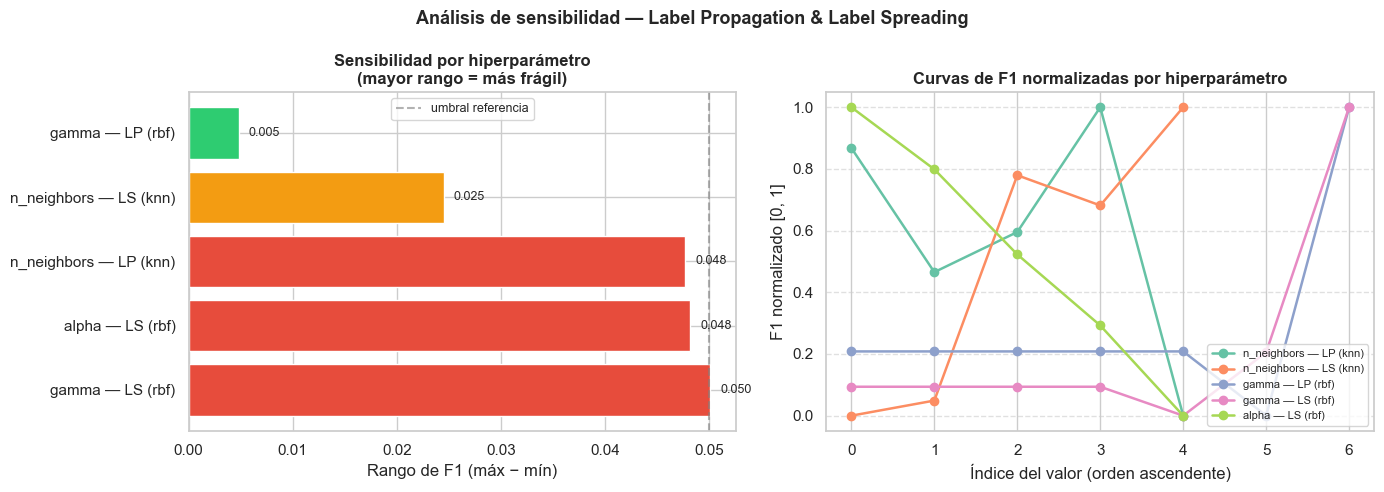

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_bar = ['#e74c3c' if r > 0.04 else '#f39c12' if r > 0.02 else '#2ecc71'
              for r in sensitivity_df['rango']]

axes[0].barh(sensitivity_df['hiperparámetro'], sensitivity_df['rango'],
             color=colors_bar, edgecolor='white')
axes[0].set_xlabel('Rango de F1 (máx − mín)')
axes[0].set_title('Sensibilidad por hiperparámetro\n(mayor rango = más frágil)',
                  fontweight='bold')
axes[0].axvline(x=0.05, color='gray', linestyle='--', alpha=0.6, label='umbral referencia')
axes[0].legend(fontsize=9)
for i, val in enumerate(sensitivity_df['rango']):
    axes[0].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

for label, vals in sensitivity_data.items():
    norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    axes[1].plot(range(len(norm)), norm, marker='o', label=label, linewidth=1.8)

axes[1].set_xlabel('Índice del valor (orden ascendente)')
axes[1].set_ylabel('F1 normalizado [0, 1]')
axes[1].set_title('Curvas de F1 normalizadas por hiperparámetro', fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Análisis de sensibilidad — Label Propagation & Label Spreading',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
best_config = {
    'label_propagation': {
        'kernel':      'knn',
        'n_neighbors': int(best_lp_k['n_neighbors']),
    },
    'label_spreading': {
        'kernel':      'knn',
        'n_neighbors': int(best_ls_k['n_neighbors']),
    }
}

print('=' * 54)
print('  CONFIGURACIÓN ÓPTIMA — Red Wine Quality')
print('=' * 54)
for modelo, params in best_config.items():
    print(f'\n  {modelo}:')
    for k, v in params.items():
        print(f'    {k} = {v}')

print('\n' + '=' * 54)
print('  Métricas con config óptima (10% etiquetado):')
print('=' * 54)

lp_final = LabelPropagation(**best_config['label_propagation'], max_iter=1000)
lp_final.fit(X_semi_b, y_semi_b)
m_lp = evaluate_model(lp_final, X_test_base, y_test_base)

ls_final = LabelSpreading(**best_config['label_spreading'], alpha=0.2)
ls_final.fit(X_semi_b, y_semi_b)
m_ls = evaluate_model(ls_final, X_test_base, y_test_base)

for nombre, m in [('Label Propagation', m_lp), ('Label Spreading', m_ls)]:
    print(f'\n  {nombre}:')
    for k, v in m.items():
        print(f'    {k} = {v}')

  CONFIGURACIÓN ÓPTIMA — Red Wine Quality

  label_propagation:
    kernel = knn
    n_neighbors = 10

  label_spreading:
    kernel = knn
    n_neighbors = 15

  Métricas con config óptima (10% etiquetado):

  Label Propagation:
    accuracy = 0.8719
    f1 = 0.851
    recall_good = 0.2558

  Label Spreading:
    accuracy = 0.875
    f1 = 0.8625
    recall_good = 0.3488


### Sensibilidad de hiperparámetros — Red Wine Quality

| Hiperparámetro | F1 mín | F1 máx | Rango | Veredicto |
|---|---|---|---|---|
| gamma — LS (rbf) | 0.7986 | 0.8487 | **0.0501** | Mayor impacto en rbf |
| alpha — LS (rbf) | 0.8053 | 0.8535 | 0.0482 | Impacto similar a gamma |
| n_neighbors — LP (knn) | 0.8033 | 0.8510 | 0.0477 | Impacto similar |
| n_neighbors — LS (knn) | 0.8380 | 0.8625 | 0.0245 | Moderado |
| gamma — LP (rbf) | 0.8023 | 0.8071 | **0.0048** | Casi irrelevante |

Todos los hiperparámetros tienen un impacto similar sobre el F1 (rangos entre
0.005 y 0.050). Ninguno domina de forma clara — esto indica que el cuello de
botella del algoritmo en este dataset no es la configuración de hiperparámetros,
sino la **escasez de señal de la clase minoritaria**: con solo 17 muestras "good"
etiquetadas, el grafo no tiene suficientes anclas para propagar correctamente sin
importar cómo se configure.

**¿Es el algoritmo robusto?**

Con kernel **knn** sí — Label Spreading mantiene F1 entre 0.838 y 0.863 en todo
el rango de k evaluado. Con kernel **rbf** no — el modelo es inestable a gamma
y consistentemente inferior a knn para este nivel de desbalance.

**Configuración óptima identificada:**

| Modelo | kernel | parámetro | valor |
|---|---|---|---|
| Label Propagation | knn | n_neighbors | 10 |
| Label Spreading | knn | n_neighbors | 15 |

Con esta configuración y 10% de datos etiquetados:
**Label Propagation → Accuracy=0.8719 | F1=0.8510 | Recall good=0.2558**
**Label Spreading   → Accuracy=0.8750 | F1=0.8625 | Recall good=0.3488**

---

## Fase 4d — Comparación por porcentaje de datos etiquetados

En esta sección se evalúa cómo cambia el desempeño de los modelos al variar la cantidad de datos etiquetados disponibles.

El objetivo principal es responder:

**¿Cuántas etiquetas son necesarias para obtener un desempeño aceptable?**

Para ello, se comparan modelos supervisados y semi-supervisados utilizando cuatro porcentajes de datos etiquetados: 5%, 10%, 15% y 20%.

Los modelos supervisados se entrenan únicamente con la porción etiquetada del conjunto de entrenamiento. Los modelos semi-supervisados utilizan esa misma porción etiquetada, pero también incorporan el resto de datos no etiquetados mediante propagación de etiquetas.

Los modelos evaluados son:

- SVM supervisado.
- Random Forest supervisado.
- Label Propagation.
- Label Spreading.

Las métricas utilizadas son accuracy, F1-score ponderado y recall de la clase positiva.

In [39]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.metrics import accuracy_score, f1_score, recall_score

label_ratios_to_evaluate = [0.05, 0.10, 0.15, 0.20]
labeled_ratio_experiment_results = []


def evaluate_classification_metrics(model, X_test, y_test):
    """
    Evalúa un modelo de clasificación con métricas consistentes
    para comparar modelos supervisados y semi-supervisados.
    """
    y_pred = model.predict(X_test)

    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_weighted': f1_score(
            y_test,
            y_pred,
            average='weighted',
            zero_division=0
        ),
        'recall_positive_class': recall_score(
            y_test,
            y_pred,
            pos_label=1,
            zero_division=0
        )
    }


for label_ratio in label_ratios_to_evaluate:
    X_train_semi, y_train_semi, X_train_labeled, y_train_labeled = create_semi_supervised_train_set(
        X_train_base,
        y_train_base,
        labeled_ratio=label_ratio,
        random_state=RANDOM_STATE
    )

    label_propagation_params = best_config['label_propagation'].copy()
    label_spreading_params = best_config['label_spreading'].copy()

    label_propagation_params.setdefault('max_iter', 1000)
    label_spreading_params.setdefault('max_iter', 1000)

    models_to_compare = {
        'SVM Supervisado': SVC(
            kernel='rbf',
            random_state=RANDOM_STATE
        ),
        'Random Forest Supervisado': RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE
        ),
        'Label Propagation': LabelPropagation(
            **label_propagation_params
        ),
        'Label Spreading': LabelSpreading(
            **label_spreading_params
        )
    }

    for model_name, model in models_to_compare.items():
        if 'Supervisado' in model_name:
            model.fit(X_train_labeled, y_train_labeled)
        else:
            model.fit(X_train_semi, y_train_semi)

        metrics = evaluate_classification_metrics(model, X_test_base, y_test_base)

        labeled_ratio_experiment_results.append({
            'porcentaje_etiquetado': int(label_ratio * 100),
            'modelo': model_name,
            'muestras_etiquetadas': len(y_train_labeled),
            'clase_0_etiquetada': int((y_train_labeled == 0).sum()),
            'clase_1_etiquetada': int((y_train_labeled == 1).sum()),
            'accuracy': metrics['accuracy'],
            'f1_weighted': metrics['f1_weighted'],
            'recall_positive_class': metrics['recall_positive_class']
        })

labeled_ratio_results_df = pd.DataFrame(labeled_ratio_experiment_results)

labeled_ratio_results_df[['accuracy', 'f1_weighted', 'recall_positive_class']] = labeled_ratio_results_df[
    ['accuracy', 'f1_weighted', 'recall_positive_class']
].round(4)

labeled_ratio_results_df

,porcentaje_etiquetado,modelo,muestras_etiquetadas,clase_0_etiquetada,clase_1_etiquetada,accuracy,f1_weighted,recall_positive_class
0,5,SVM Supervisado,63,54,9,0.8656,0.8033,0.0000
1,5,Random Forest Supervisado,63,54,9,0.8719,0.8275,0.0930
2,5,Label Propagation,63,54,9,0.8656,0.8033,0.0000
3,5,Label Spreading,63,54,9,0.8594,0.8195,0.0930
4,10,SVM Supervisado,127,110,17,0.8656,0.8033,0.0000
5,10,Random Forest Supervisado,127,110,17,0.8812,0.8459,0.1628
6,10,Label Propagation,127,110,17,0.8719,0.8510,0.2558
7,10,Label Spreading,127,110,17,0.8750,0.8625,0.3488
8,15,SVM Supervisado,191,165,26,0.8812,0.8381,0.1163
9,15,Random Forest Supervisado,191,165,26,0.8969,0.8705,0.2558


---

## Fase 4e — Curvas de desempeño y análisis final

A partir de los resultados obtenidos en la variación del porcentaje de datos etiquetados, se generan curvas de desempeño para comparar visualmente el comportamiento de los modelos supervisados y semi-supervisados.

Estas visualizaciones permiten analizar si el desempeño mejora conforme aumenta la cantidad de etiquetas disponibles y si los métodos semi-supervisados logran superar al baseline supervisado cuando se trabaja con pocos datos etiquetados.


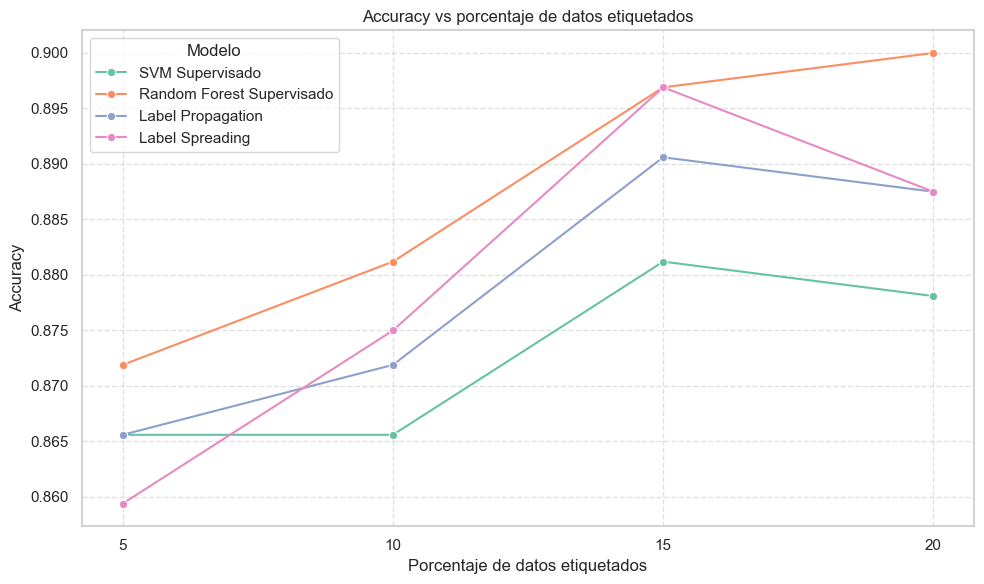

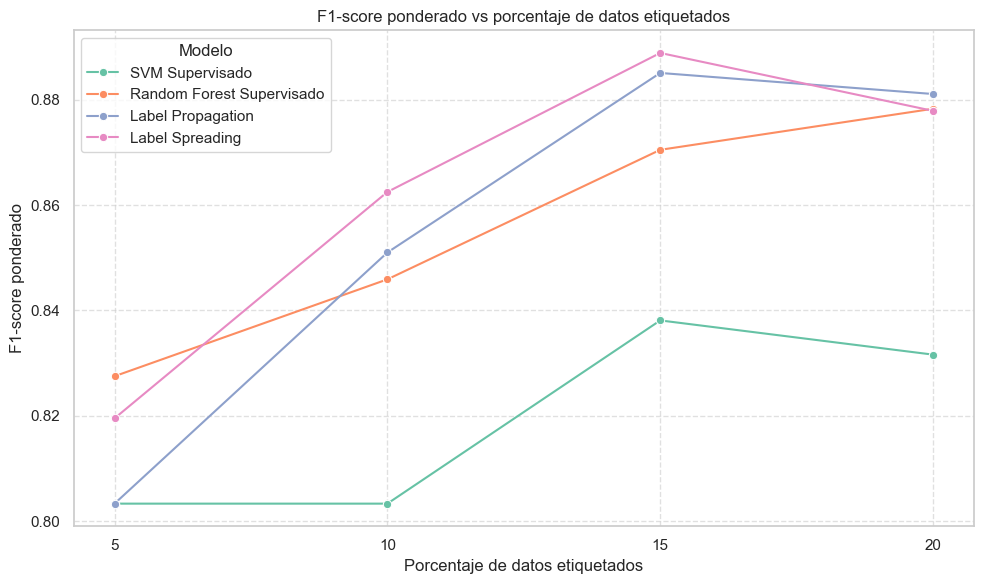

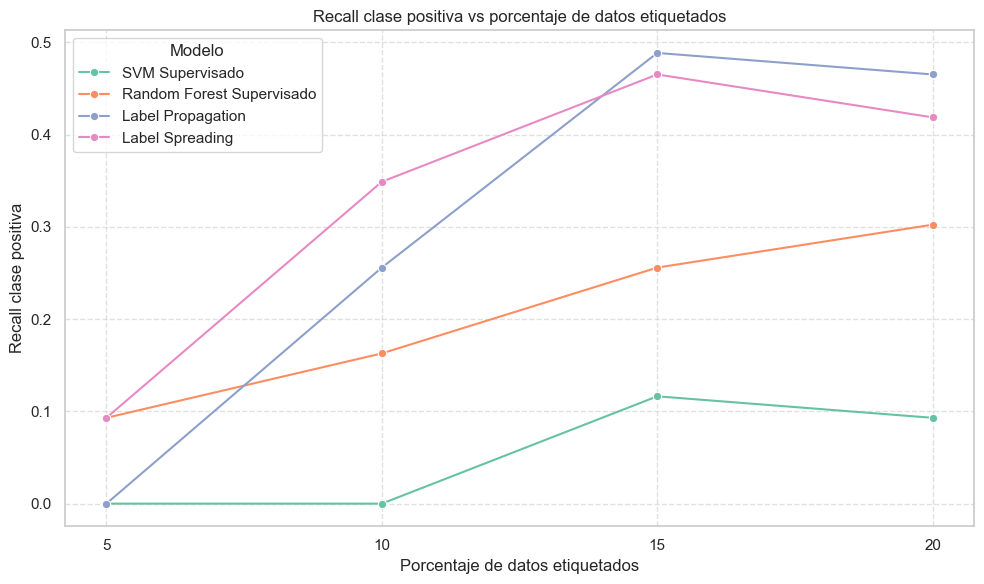

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

metrics_to_plot = {
    'accuracy': 'Accuracy',
    'f1_weighted': 'F1-score ponderado',
    'recall_positive_class': 'Recall clase positiva'
}

for metric, metric_label in metrics_to_plot.items():
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=labeled_ratio_results_df,
        x='porcentaje_etiquetado',
        y=metric,
        hue='modelo',
        marker='o'
    )

    plt.title(f'{metric_label} vs porcentaje de datos etiquetados')
    plt.xlabel('Porcentaje de datos etiquetados')
    plt.ylabel(metric_label)
    plt.xticks([5, 10, 15, 20])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Modelo')
    plt.tight_layout()
    plt.show()


In [41]:
# Mejor modelo por porcentaje de etiquetas usando F1-score ponderado
best_model_by_label_ratio = (
    labeled_ratio_results_df
    .sort_values(['porcentaje_etiquetado', 'f1_weighted'], ascending=[True, False])
    .groupby('porcentaje_etiquetado')
    .first()
    .reset_index()
)

display(best_model_by_label_ratio[[
    'porcentaje_etiquetado',
    'modelo',
    'accuracy',
    'f1_weighted',
    'recall_positive_class'
]])

# Comparación directa entre el mejor modelo supervisado y el mejor semi-supervisado
labeled_ratio_results_with_type = labeled_ratio_results_df.copy()
labeled_ratio_results_with_type['tipo_modelo'] = labeled_ratio_results_with_type['modelo'].apply(
    lambda model_name: 'Supervisado' if 'Supervisado' in model_name else 'Semi-supervisado'
)

best_f1_by_approach = (
    labeled_ratio_results_with_type
    .groupby(['porcentaje_etiquetado', 'tipo_modelo'])['f1_weighted']
    .max()
    .reset_index()
)

label_ratio_comparison_df = (
    best_f1_by_approach
    .pivot(
        index='porcentaje_etiquetado',
        columns='tipo_modelo',
        values='f1_weighted'
    )
    .reset_index()
)

label_ratio_comparison_df['diferencia_f1_semi_vs_supervisado'] = (
    label_ratio_comparison_df['Semi-supervisado'] -
    label_ratio_comparison_df['Supervisado']
).round(4)

display(label_ratio_comparison_df)


,porcentaje_etiquetado,modelo,accuracy,f1_weighted,recall_positive_class
0,5,Random Forest Supervisado,0.8719,0.8275,0.0930
1,10,Label Spreading,0.8750,0.8625,0.3488
2,15,Label Spreading,0.8969,0.8889,0.4651
3,20,Label Propagation,0.8875,0.8811,0.4651


tipo_modelo,porcentaje_etiquetado,Semi-supervisado,Supervisado,diferencia_f1_semi_vs_supervisado
0,5,0.8195,0.8275,-0.0080
1,10,0.8625,0.8459,0.0166
2,15,0.8889,0.8705,0.0184
3,20,0.8811,0.8783,0.0028


### Interpretación de las curvas de desempeño

Las curvas permiten comparar el comportamiento de los modelos conforme aumenta la proporción de datos etiquetados. En este experimento se mantiene fija la configuración óptima obtenida en la etapa de sensibilidad de hiperparámetros y solo se modifica el porcentaje de etiquetas disponibles.

Los modelos supervisados se entrenan únicamente con las muestras etiquetadas. Por ello, cuando el porcentaje de etiquetas es bajo, su desempeño puede ser más inestable, ya que el modelo cuenta con menos ejemplos reales para aprender la frontera de decisión.

Los modelos semi-supervisados, en cambio, utilizan los datos etiquetados y también la estructura de los datos no etiquetados. Label Propagation y Label Spreading construyen un grafo de similitud entre observaciones y propagan las etiquetas hacia puntos cercanos o similares.

La tabla de mejor modelo por porcentaje permite identificar cuál algoritmo obtiene el mayor F1-score ponderado en cada escenario. Además, la comparación entre el mejor modelo supervisado y el mejor semi-supervisado permite ver si el enfoque semi-supervisado realmente aporta valor cuando hay pocas etiquetas.

Si la diferencia `diferencia_f1_semi_vs_supervisado` es positiva, significa que el mejor modelo semi-supervisado superó al mejor modelo supervisado para ese porcentaje de etiquetas. Si la diferencia es negativa, el baseline supervisado obtuvo mejor desempeño.


---

## Fase 5 — Visualización

En esta fase se consolidan los resultados de las fases anteriores en visualizaciones
finales.

### 5a.1 — Curvas de desempeño vs porcentaje de datos etiquetados

Se consolidan en un solo panel las tres métricas evaluadas en la Fase 4d (accuracy,
F1 ponderado y recall de la clase positiva *good*) para los cuatro modelos en
comparación. Los modelos **supervisados** se grafican con línea punteada y marcador
hueco, los **semi-supervisados** con línea sólida y marcador relleno. Una estrella
dorada señala el mejor modelo en cada porcentaje según la métrica del subplot.

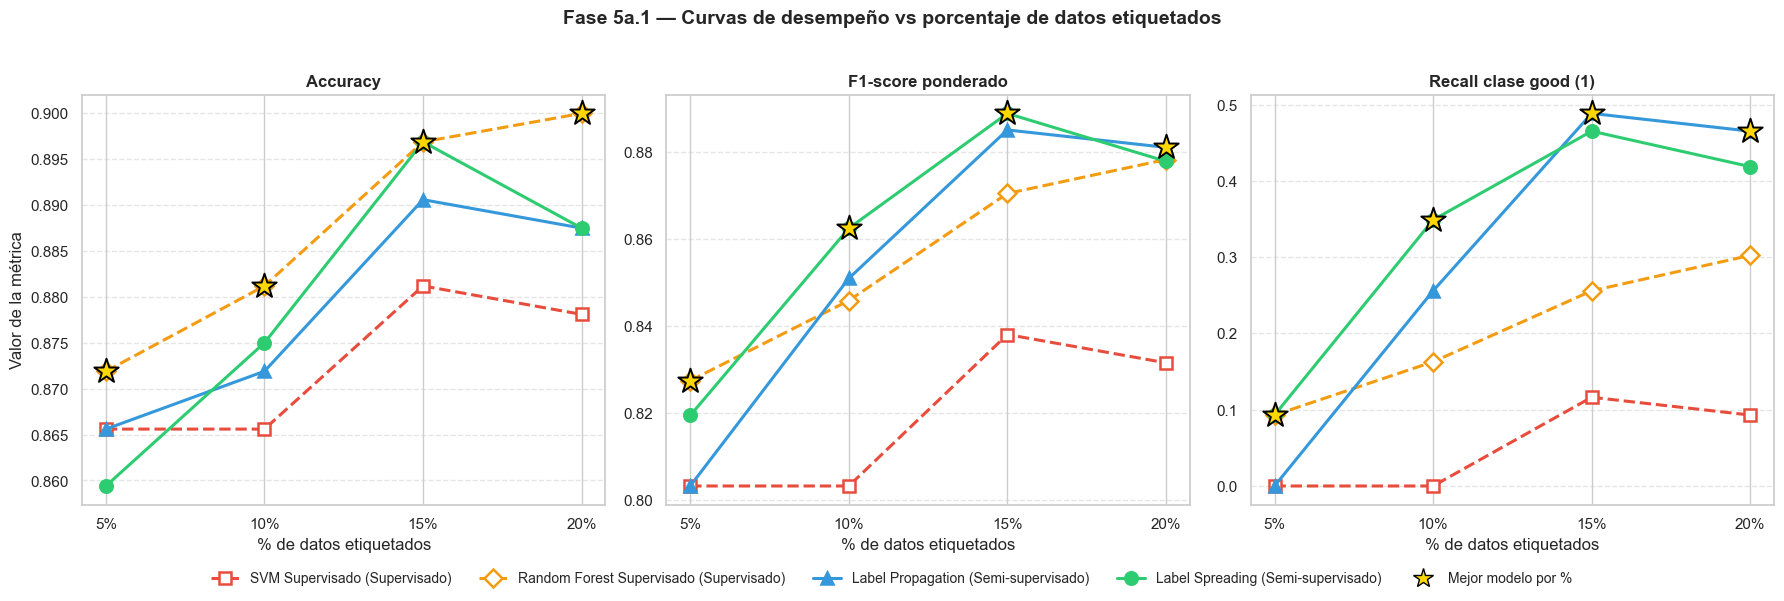

In [42]:
import matplotlib.pyplot as plt

#configuracion visual: estilo segun tipo (supervisado vs semi-supervisado) y color por modelo
model_styles = {
    'SVM Supervisado':           {'color': '#e74c3c', 'linestyle': '--', 'marker': 's', 'tipo': 'Supervisado'},
    'Random Forest Supervisado': {'color': '#f39c12', 'linestyle': '--', 'marker': 'D', 'tipo': 'Supervisado'},
    'Label Propagation':         {'color': '#3498db', 'linestyle': '-',  'marker': '^', 'tipo': 'Semi-supervisado'},
    'Label Spreading':           {'color': '#2ecc71', 'linestyle': '-',  'marker': 'o', 'tipo': 'Semi-supervisado'},
}

metrics_panel = [
    ('accuracy',              'Accuracy'),
    ('f1_weighted',           'F1-score ponderado'),
    ('recall_positive_class', 'Recall clase good (1)'),
]

percentages = sorted(labeled_ratio_results_df['porcentaje_etiquetado'].unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True)

for ax, (metric, metric_label) in zip(axes, metrics_panel):
    #una linea por modelo; relleno solido para semi-supervisado, hueco para supervisado
    for model_name, style in model_styles.items():
        subset = (labeled_ratio_results_df[labeled_ratio_results_df['modelo'] == model_name]
                  .sort_values('porcentaje_etiquetado'))
        face = style['color'] if style['tipo'] == 'Semi-supervisado' else 'white'
        ax.plot(subset['porcentaje_etiquetado'], subset[metric],
                color=style['color'], linestyle=style['linestyle'],
                marker=style['marker'], markersize=9, linewidth=2.2,
                label=f"{model_name} ({style['tipo']})",
                markerfacecolor=face, markeredgecolor=style['color'],
                markeredgewidth=1.8)

    #estrella dorada: mejor modelo por porcentaje segun la metrica del subplot
    for pct in percentages:
        pct_subset = labeled_ratio_results_df[labeled_ratio_results_df['porcentaje_etiquetado'] == pct]
        best_row = pct_subset.loc[pct_subset[metric].idxmax()]
        ax.scatter(best_row['porcentaje_etiquetado'], best_row[metric],
                   marker='*', s=340, color='gold', edgecolor='black',
                   linewidth=1.4, zorder=5)

    ax.set_title(metric_label, fontsize=12, fontweight='bold')
    ax.set_xlabel('% de datos etiquetados')
    ax.set_xticks(percentages)
    ax.set_xticklabels([f'{p}%' for p in percentages])
    ax.grid(axis='y', linestyle='--', alpha=0.5)

axes[0].set_ylabel('Valor de la métrica')

#leyenda unificada en la parte inferior, incluyendo la marca de "mejor modelo"
handles, labels = axes[0].get_legend_handles_labels()
star_handle = plt.Line2D([0], [0], marker='*', color='w',
                         markerfacecolor='gold', markeredgecolor='black',
                         markersize=15, linestyle='', label='Mejor modelo por %')
fig.legend(handles=handles + [star_handle],
           loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.suptitle('Fase 5a.1 — Curvas de desempeño vs porcentaje de datos etiquetados',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Ganancia semi-supervisada vs baseline supervisado

Para cuantificar el aporte real del enfoque semi-supervisado se compara, por cada
porcentaje de etiquetas, el **mejor F1 ponderado obtenido por un modelo supervisado**
contra el **mejor F1 obtenido por un modelo semi-supervisado**. Una barra verde
indica que el enfoque semi-supervisado supera al supervisado en ese escenario; una
barra roja indica lo contrario.

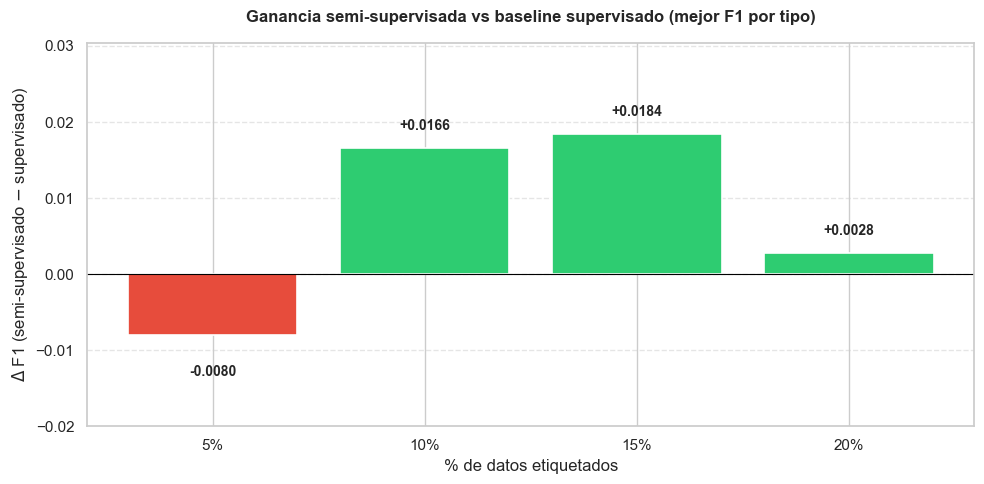

=== Tabla detallada — mejor F1 por tipo y brecha ===
tipo                   Semi-supervisado  Supervisado     gap
porcentaje_etiquetado                                       
5                                0.8195       0.8275 -0.0080
10                               0.8625       0.8459  0.0166
15                               0.8889       0.8705  0.0184
20                               0.8811       0.8783  0.0028


In [44]:
#brecha de f1 entre el mejor modelo semi-supervisado y el mejor supervisado por %
gap_df = labeled_ratio_results_df.copy()
gap_df['tipo'] = gap_df['modelo'].apply(
    lambda m: 'Supervisado' if 'Supervisado' in m else 'Semi-supervisado'
)

best_per_type = (gap_df.groupby(['porcentaje_etiquetado', 'tipo'])['f1_weighted']
                       .max()
                       .reset_index()
                       .pivot(index='porcentaje_etiquetado',
                              columns='tipo',
                              values='f1_weighted'))
best_per_type['gap'] = best_per_type['Semi-supervisado'] - best_per_type['Supervisado']

fig, ax = plt.subplots(figsize=(10, 5))
colors_gap = ['#2ecc71' if g >= 0 else '#e74c3c' for g in best_per_type['gap']]
x_labels = [f'{int(p)}%' for p in best_per_type.index]
bars = ax.bar(x_labels, best_per_type['gap'],
              color=colors_gap, edgecolor='white', linewidth=1.2)

#anotar cada barra con su delta
for bar, value in zip(bars, best_per_type['gap']):
    offset = 0.002 if value >= 0 else -0.004
    va = 'bottom' if value >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, value + offset,
            f'{value:+.4f}', ha='center', va=va, fontsize=10, fontweight='bold')

#headroom en el eje y para que los labels no choquen con el titulo
gap_max = best_per_type['gap'].max()
gap_min = best_per_type['gap'].min()
y_top    = max(gap_max, 0) + 0.012
y_bottom = min(gap_min, 0) - 0.012
ax.set_ylim(y_bottom, y_top)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Ganancia semi-supervisada vs baseline supervisado (mejor F1 por tipo)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('% de datos etiquetados')
ax.set_ylabel(r'$\Delta$ F1 (semi-supervisado $-$ supervisado)')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('=== Tabla detallada — mejor F1 por tipo y brecha ===')
print(best_per_type.round(4).to_string())

### 5a.2 — Matrices de confusión

Las curvas de la sección anterior muestran *cuánto* acierta cada modelo, pero no
*dónde* se equivoca. Para responder eso se generan matrices de confusión sobre el
conjunto de prueba fijando `labeled_ratio = 0.10` (el escenario sobre el que se
seleccionaron los hiperparámetros óptimos en la Fase 4). Cada celda muestra el
conteo absoluto de muestras y, entre paréntesis, la proporción normalizada por
clase verdadera — equivalente al recall de cada clase. El color escala según la
proporción para resaltar visualmente la diagonal (aciertos) frente a los
fuera-de-diagonal (errores).

Con el desbalance 86/14 del dataset, el número absoluto de falsos negativos en la
clase `good` es la métrica más relevante: cada FN representa un vino de calidad
que el modelo etiquetó como `bad`.

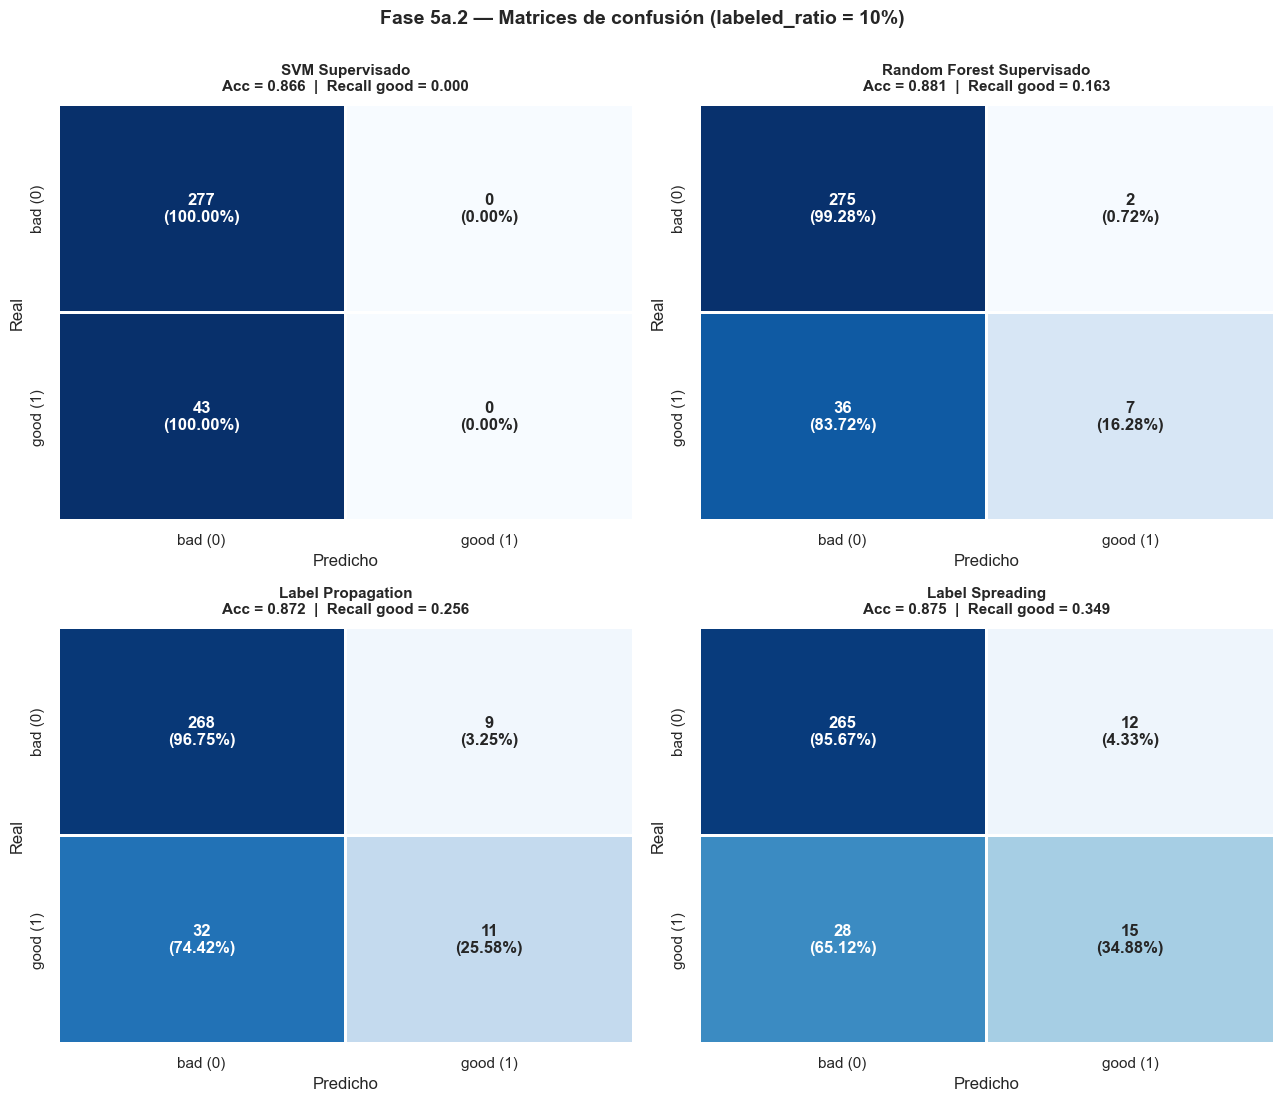

In [45]:
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
import seaborn as sns

CM_RATIO = 0.10

#regenerar el subconjunto al 10% etiquetado con la misma semilla usada en fase 4
X_cm_semi, y_cm_semi, X_cm_lab, y_cm_lab = create_semi_supervised_train_set(
    X_train_base, y_train_base, CM_RATIO, random_state=RANDOM_STATE
)

#entrenar los 4 modelos con la configuracion optima identificada en fase 4
cm_models = {
    'SVM Supervisado':           SVC(kernel='rbf', random_state=RANDOM_STATE),
    'Random Forest Supervisado': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Label Propagation':         LabelPropagation(**best_config['label_propagation'], max_iter=1000),
    'Label Spreading':           LabelSpreading(**best_config['label_spreading'], alpha=0.2, max_iter=1000),
}

cm_predictions = {}
for name, model in cm_models.items():
    if 'Supervisado' in name:
        model.fit(X_cm_lab, y_cm_lab)
    else:
        model.fit(X_cm_semi, y_cm_semi)
    cm_predictions[name] = model.predict(X_test_base)

class_labels = ['bad (0)', 'good (1)']

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes_flat = axes.flatten()

for ax, (name, y_pred) in zip(axes_flat, cm_predictions.items()):
    cm_counts = confusion_matrix(y_test_base, y_pred, labels=[0, 1])
    cm_norm   = cm_counts / cm_counts.sum(axis=1, keepdims=True)

    #anotacion combinada: conteo absoluto + proporcion normalizada por clase real
    annotations = [[f'{cm_counts[i, j]}\n({cm_norm[i, j]:.2%})'
                    for j in range(cm_counts.shape[1])]
                   for i in range(cm_counts.shape[0])]

    sns.heatmap(cm_norm, annot=annotations, fmt='', cmap='Blues',
                cbar=False, ax=ax, linewidths=1, linecolor='white',
                xticklabels=class_labels, yticklabels=class_labels,
                vmin=0, vmax=1, annot_kws={'fontsize': 12, 'fontweight': 'bold'})

    #titulo con el accuracy y el recall de la clase good para contextualizar
    tn, fp, fn, tp = cm_counts.ravel()
    acc = (tn + tp) / cm_counts.sum()
    recall_good = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    ax.set_title(f'{name}\nAcc = {acc:.3f}  |  Recall good = {recall_good:.3f}',
                 fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle(f'Fase 5a.2 — Matrices de confusión (labeled_ratio = {int(CM_RATIO*100)}%)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

#### Distribución de errores por modelo

Para una lectura más directa de qué clase de error comete cada modelo se separan
los falsos positivos (vinos `bad` clasificados como `good`) y los falsos negativos
(vinos `good` clasificados como `bad`). En un dataset desbalanceado como éste, un
modelo trivial que prediga siempre la clase mayoritaria minimiza los falsos
positivos a cero pero acumula todos los falsos negativos posibles.

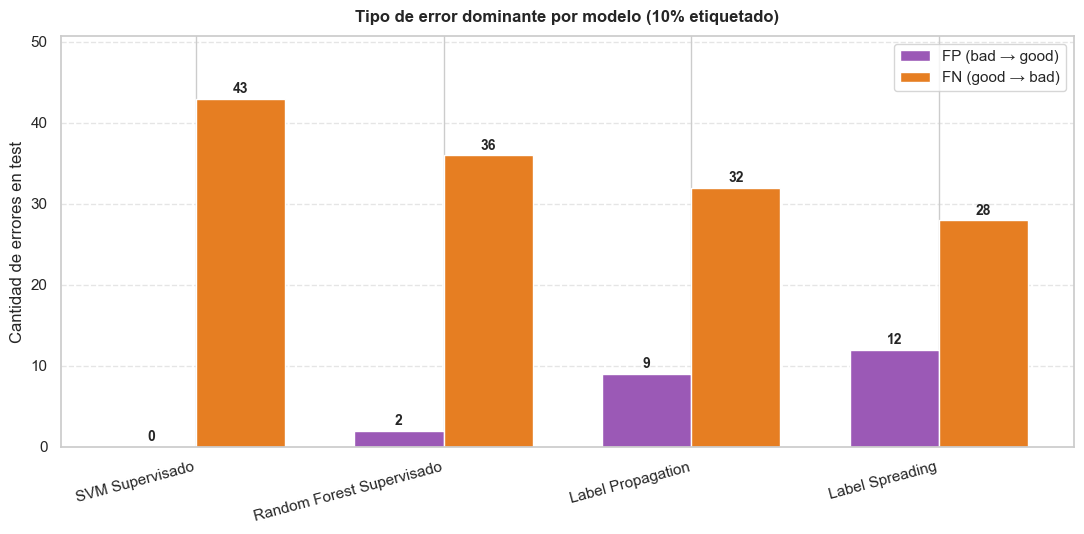

=== Conteo de errores por modelo ===
                           FP (bad→good)  FN (good→bad)
modelo                                                 
SVM Supervisado                        0             43
Random Forest Supervisado              2             36
Label Propagation                      9             32
Label Spreading                       12             28


In [46]:
#extraer fp y fn por modelo para comparar el tipo de error dominante
error_breakdown = []
for name, y_pred in cm_predictions.items():
    cm_counts = confusion_matrix(y_test_base, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm_counts.ravel()
    error_breakdown.append({'modelo': name, 'FP (bad→good)': fp, 'FN (good→bad)': fn})

error_df = pd.DataFrame(error_breakdown).set_index('modelo')

fig, ax = plt.subplots(figsize=(11, 5.5))
x_pos   = np.arange(len(error_df))
bar_w   = 0.36

bars_fp = ax.bar(x_pos - bar_w/2, error_df['FP (bad→good)'], bar_w,
                 color='#9b59b6', edgecolor='white', label='FP (bad → good)')
bars_fn = ax.bar(x_pos + bar_w/2, error_df['FN (good→bad)'], bar_w,
                 color='#e67e22', edgecolor='white', label='FN (good → bad)')

#anotar cada barra con su conteo
for bars in (bars_fp, bars_fn):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.7,
                f'{int(h)}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(error_df.index, rotation=15, ha='right')
ax.set_ylabel('Cantidad de errores en test')
ax.set_title('Tipo de error dominante por modelo (10% etiquetado)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylim(0, error_df.values.max() * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print('=== Conteo de errores por modelo ===')
print(error_df.to_string())

### 5a.3 — Evolución del error

La evolución del error se analiza desde dos ángulos complementarios:

1. **Error externo (vs cantidad de etiquetas):** cómo decrece la tasa de error en el
   conjunto de prueba cuando aumenta el porcentaje de datos etiquetados. Se reporta
   por separado el **error global** (`1 − accuracy`) y el **error en la clase
   minoritaria** (`1 − recall_good`), porque en un dataset con desbalance 86/14 el
   error global puede ser engañoso — un modelo que nunca predice `good` tiene un
   error global aceptable pero un error de la clase minoritaria del 100%.

2. **Error interno (durante la propagación):** cómo se estabiliza el error de Label
   Propagation y Label Spreading conforme aumenta el número de iteraciones del
   algoritmo. Se hace un barrido de `max_iter` y se registra el error en test tras
   cada corte, lo que permite ver el *régimen transitorio* del grafo antes de que
   la propagación converja al punto fijo de la matriz de transición.

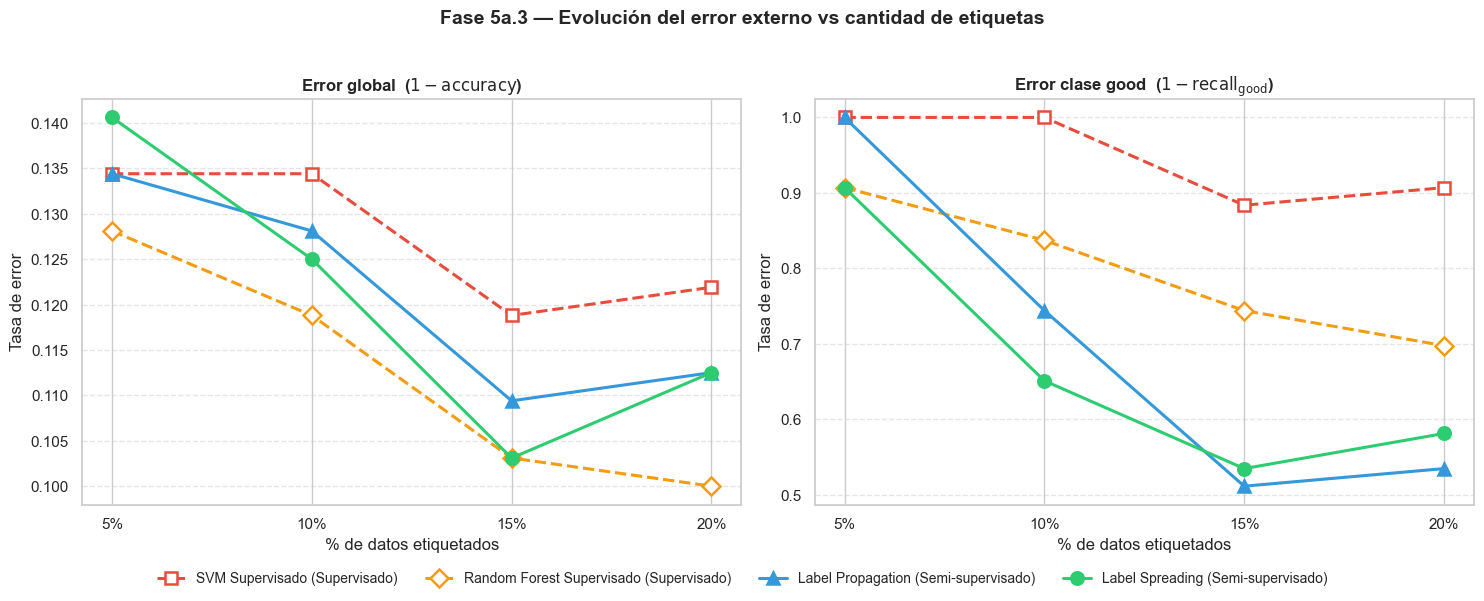

=== Tasas de error por modelo y porcentaje ===
                           error_global                                                                  error_good                                                          
modelo                Label Propagation Label Spreading Random Forest Supervisado SVM Supervisado Label Propagation Label Spreading Random Forest Supervisado SVM Supervisado
porcentaje_etiquetado                                                                                                                                                        
5                                0.1344          0.1406                    0.1281          0.1344            1.0000          0.9070                    0.9070          1.0000
10                               0.1281          0.1250                    0.1188          0.1344            0.7442          0.6512                    0.8372          1.0000
15                               0.1094          0.1031                    0.1031  

In [47]:
#error en test por modelo y porcentaje de etiquetas
error_evolution_df = labeled_ratio_results_df.copy()
error_evolution_df['error_global']    = 1 - error_evolution_df['accuracy']
error_evolution_df['error_good']      = 1 - error_evolution_df['recall_positive_class']

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True)

error_metrics = [
    ('error_global', 'Error global  ($1 - \mathrm{accuracy}$)'),
    ('error_good',   'Error clase good  ($1 - \mathrm{recall}_{\mathrm{good}}$)'),
]

for ax, (metric_col, metric_title) in zip(axes, error_metrics):
    for model_name, style in model_styles.items():
        subset = (error_evolution_df[error_evolution_df['modelo'] == model_name]
                  .sort_values('porcentaje_etiquetado'))
        face = style['color'] if style['tipo'] == 'Semi-supervisado' else 'white'
        ax.plot(subset['porcentaje_etiquetado'], subset[metric_col],
                color=style['color'], linestyle=style['linestyle'],
                marker=style['marker'], markersize=9, linewidth=2.2,
                label=f"{model_name} ({style['tipo']})",
                markerfacecolor=face, markeredgecolor=style['color'],
                markeredgewidth=1.8)

    ax.set_title(metric_title, fontsize=12, fontweight='bold')
    ax.set_xlabel('% de datos etiquetados')
    ax.set_ylabel('Tasa de error')
    ax.set_xticks(percentages)
    ax.set_xticklabels([f'{p}%' for p in percentages])
    ax.grid(axis='y', linestyle='--', alpha=0.5)

#leyenda unica abajo
handles, _ = axes[0].get_legend_handles_labels()
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.suptitle('Fase 5a.3 — Evolución del error externo vs cantidad de etiquetas',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('=== Tasas de error por modelo y porcentaje ===')
err_pivot = error_evolution_df.pivot_table(
    index='porcentaje_etiquetado',
    columns='modelo',
    values=['error_global', 'error_good']
).round(4)
print(err_pivot.to_string())

#### Convergencia interna de Label Propagation y Label Spreading

Label Propagation y Label Spreading actualizan iterativamente la matriz de
etiquetas siguiendo $Y^{(t+1)} = T \cdot Y^{(t)}$ (con $T$ la matriz de transición
del grafo). El algoritmo converge cuando $\|Y^{(t+1)} - Y^{(t)}\| < \mathrm{tol}$
o se alcanza `max_iter`. A continuación se fuerza un corte temprano variando
`max_iter` de 1 a 60 y se registra el error en test tras cada ejecución, fijando
`labeled_ratio = 0.10` y la configuración óptima de la Fase 4. La línea vertical
marca el `n_iter_` reportado por el modelo cuando se le permite converger
libremente — todo lo que está a la derecha de esa línea es ruido numérico.

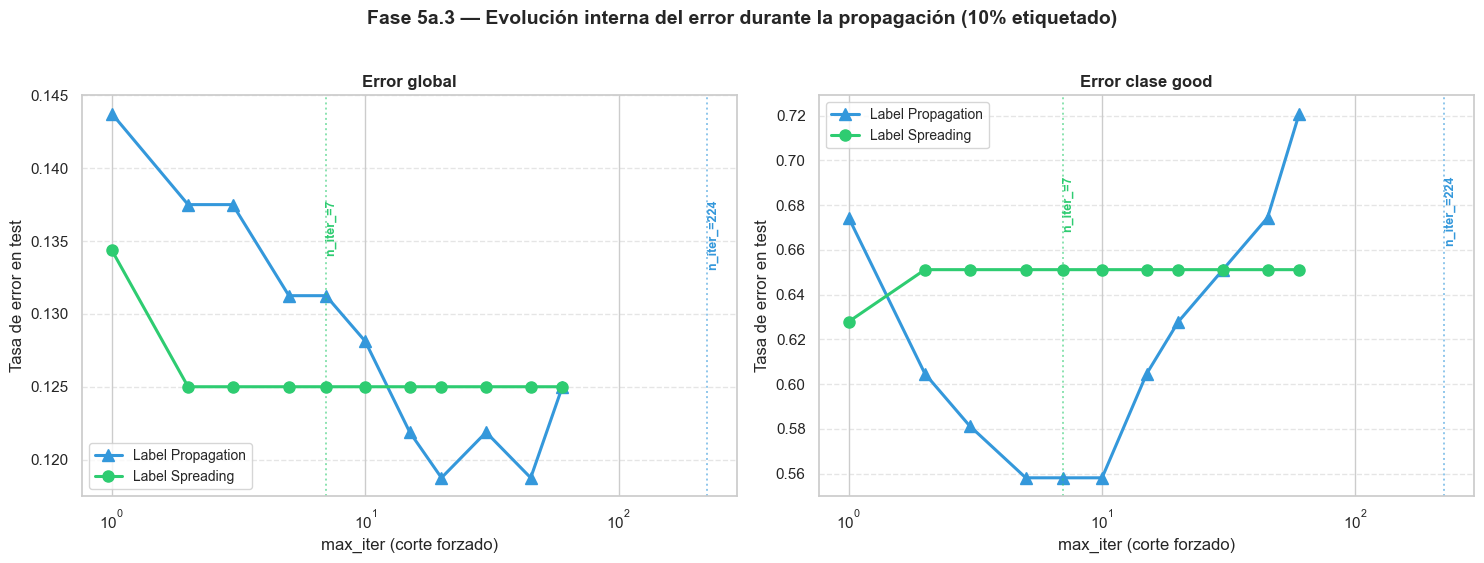


Convergencia libre — Label Propagation: 224 iteraciones
Convergencia libre — Label Spreading:   7 iteraciones


In [48]:
#sweep de max_iter sobre lp y ls para observar la dinamica de la propagacion
max_iter_grid = [1, 2, 3, 5, 7, 10, 15, 20, 30, 45, 60]

internal_results = []
for n_iter in max_iter_grid:
    lp_iter = LabelPropagation(**best_config['label_propagation'], max_iter=n_iter, tol=1e-12)
    lp_iter.fit(X_cm_semi, y_cm_semi)
    y_pred_lp = lp_iter.predict(X_test_base)
    cm_lp = confusion_matrix(y_test_base, y_pred_lp, labels=[0, 1])
    tn, fp, fn, tp = cm_lp.ravel()
    internal_results.append({
        'modelo': 'Label Propagation', 'max_iter': n_iter,
        'error_global': 1 - (tn + tp) / cm_lp.sum(),
        'error_good':   1 - (tp / (tp + fn)) if (tp + fn) > 0 else 1.0,
    })

    ls_iter = LabelSpreading(**best_config['label_spreading'], alpha=0.2,
                              max_iter=n_iter, tol=1e-12)
    ls_iter.fit(X_cm_semi, y_cm_semi)
    y_pred_ls = ls_iter.predict(X_test_base)
    cm_ls = confusion_matrix(y_test_base, y_pred_ls, labels=[0, 1])
    tn, fp, fn, tp = cm_ls.ravel()
    internal_results.append({
        'modelo': 'Label Spreading', 'max_iter': n_iter,
        'error_global': 1 - (tn + tp) / cm_ls.sum(),
        'error_good':   1 - (tp / (tp + fn)) if (tp + fn) > 0 else 1.0,
    })

internal_df = pd.DataFrame(internal_results)

#capturar el n_iter_ real al que cada modelo converge libremente
lp_full = LabelPropagation(**best_config['label_propagation'], max_iter=1000)
lp_full.fit(X_cm_semi, y_cm_semi)
ls_full = LabelSpreading(**best_config['label_spreading'], alpha=0.2, max_iter=1000)
ls_full.fit(X_cm_semi, y_cm_semi)

converge_at = {
    'Label Propagation': int(lp_full.n_iter_),
    'Label Spreading':   int(ls_full.n_iter_),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True)

for ax, (metric_col, metric_title) in zip(axes, [
    ('error_global', 'Error global'),
    ('error_good',   'Error clase good'),
]):
    for model_name in ['Label Propagation', 'Label Spreading']:
        style = model_styles[model_name]
        subset = internal_df[internal_df['modelo'] == model_name].sort_values('max_iter')
        ax.plot(subset['max_iter'], subset[metric_col],
                color=style['color'], linestyle=style['linestyle'],
                marker=style['marker'], markersize=8, linewidth=2.2,
                label=model_name, markerfacecolor=style['color'],
                markeredgecolor=style['color'])

        #linea vertical en el n_iter_ real de cada modelo
        ax.axvline(converge_at[model_name], color=style['color'],
                   linestyle=':', alpha=0.55, linewidth=1.4)
        ax.text(converge_at[model_name], ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 1,
                f'  n_iter_={converge_at[model_name]}',
                color=style['color'], fontsize=9, fontweight='bold',
                va='top', ha='left', rotation=90)

    ax.set_title(metric_title, fontsize=12, fontweight='bold')
    ax.set_xlabel('max_iter (corte forzado)')
    ax.set_ylabel('Tasa de error en test')
    ax.set_xscale('log')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(fontsize=10)

plt.suptitle('Fase 5a.3 — Evolución interna del error durante la propagación (10% etiquetado)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nConvergencia libre — Label Propagation: {converge_at["Label Propagation"]} iteraciones')
print(f'Convergencia libre — Label Spreading:   {converge_at["Label Spreading"]} iteraciones')

---
### 5b — Predicciones vs Valores Reales

Para comparar directamente lo que predice cada modelo contra la etiqueta real, se visualizan las predicciones del conjunto de test como **barras apiladas** con los cuatro componentes de la matriz de confusión:

- **TP** (Verdaderos Positivos): predicho `good`, real `good`
- **TN** (Verdaderos Negativos): predicho `bad`, real `bad`
- **FP** (Falsos Positivos): predicho `good`, real `bad`
- **FN** (Falsos Negativos): predicho `bad`, real `good`

Cada barra suma el 100 % de las muestras de test, permitiendo ver de un vistazo cuánto peso tiene cada tipo de error en cada modelo.

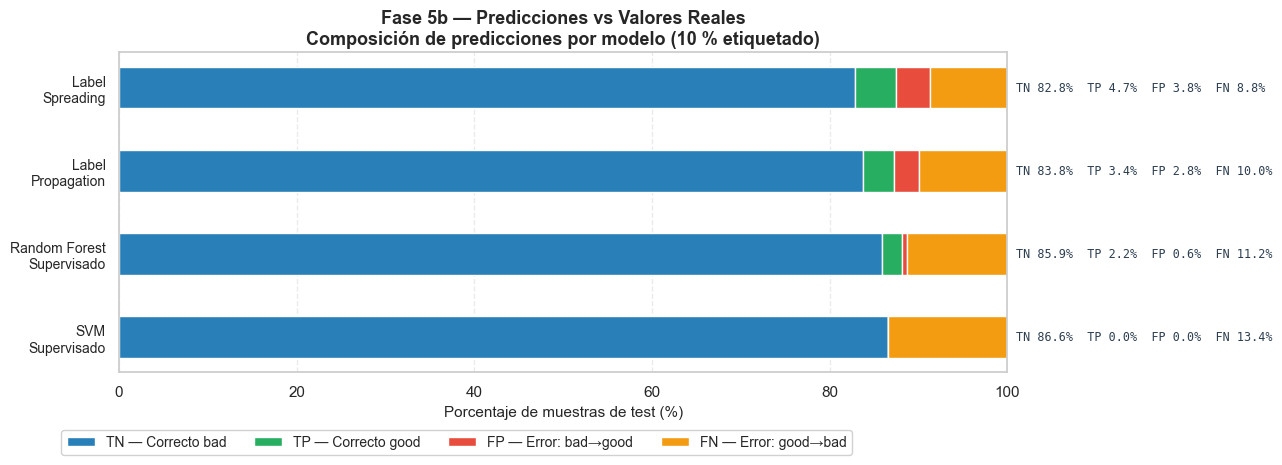

Total muestras de test: 320
Modelo                             TN     TP     FP     FN
------------------------------------------------------
SVM Supervisado                 86.6%   0.0%   0.0%  13.4%
Random Forest Supervisado       85.9%   2.2%   0.6%  11.2%
Label Propagation               83.8%   3.4%   2.8%  10.0%
Label Spreading                 82.8%   4.7%   3.8%   8.8%


In [54]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

model_names_order = list(cm_predictions.keys())
n_total = len(y_test_base)

# Extraer TP, TN, FP, FN para cada modelo
tp_list, tn_list, fp_list, fn_list = [], [], [], []
for name in model_names_order:
    cm = confusion_matrix(y_test_base, cm_predictions[name], labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    tn_list.append(tn / n_total * 100)
    fp_list.append(fp / n_total * 100)
    fn_list.append(fn / n_total * 100)
    tp_list.append(tp / n_total * 100)

short_names = ['SVM\nSupervisado', 'Random Forest\nSupervisado',
               'Label\nPropagation', 'Label\nSpreading']

colors = {'TN': '#2980b9', 'TP': '#27ae60', 'FP': '#e74c3c', 'FN': '#f39c12'}

fig, ax = plt.subplots(figsize=(13, 5))

y = np.arange(len(model_names_order))
height = 0.50

b_tn = ax.barh(y, tn_list, height, label='TN — Correcto bad',  color=colors['TN'])
b_tp = ax.barh(y, tp_list, height, left=tn_list,              label='TP — Correcto good', color=colors['TP'])
b_fp = ax.barh(y, fp_list, height,
               left=[a+b for a,b in zip(tn_list, tp_list)],
               label='FP — Error: bad→good', color=colors['FP'])
b_fn = ax.barh(y, fn_list, height,
               left=[a+b+c for a,b,c in zip(tn_list, tp_list, fp_list)],
               label='FN — Error: good→bad', color=colors['FN'])

# Etiqueta resumen a la derecha de cada barra (siempre visible)
for i, (tn, tp, fp, fn) in enumerate(zip(tn_list, tp_list, fp_list, fn_list)):
    label = f'TN {tn:.1f}%  TP {tp:.1f}%  FP {fp:.1f}%  FN {fn:.1f}%'
    ax.text(101, y[i], label, va='center', ha='left', fontsize=8.5,
            fontfamily='monospace',
            color='#2c3e50')

ax.set_yticks(y)
ax.set_yticklabels(short_names, fontsize=10)
ax.set_xlabel('Porcentaje de muestras de test (%)', fontsize=11)
ax.set_xlim(0, 100)
ax.set_title(
    'Fase 5b — Predicciones vs Valores Reales\n'
    'Composición de predicciones por modelo (10 % etiquetado)',
    fontsize=13, fontweight='bold')
ax.legend(loc='lower center', bbox_to_anchor=(0.38, -0.28),
          ncol=4, fontsize=10, framealpha=0.9)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f'Total muestras de test: {n_total}')
print(f"{'Modelo':<30} {'TN':>6} {'TP':>6} {'FP':>6} {'FN':>6}")
print('-' * 54)
for name, tn, tp, fp, fn in zip(model_names_order, tn_list, tp_list, fp_list, fn_list):
    print(f"{name:<30} {tn:>5.1f}% {tp:>5.1f}% {fp:>5.1f}% {fn:>5.1f}%")

---
### 5c — Gráficos adicionales para presentación y discusión

A continuación se presentan tres visualizaciones complementarias que enriquecen el análisis de los modelos semi-supervisados desde distintas perspectivas:

1. **Curvas ROC** — comparan la capacidad discriminativa de cada modelo medida por el AUC, independientemente del umbral de clasificación.
2. **Propagación de etiquetas en espacio PCA** — muestra gráficamente cómo Label Propagation asigna etiquetas a los puntos no supervisados, haciendo visible el mecanismo del algoritmo.
3. **Importancia de features (Random Forest)** — identifica qué variables fisicoquímicas del vino tienen mayor peso en la clasificación, útil para validar la coherencia del modelo con el dominio del problema.

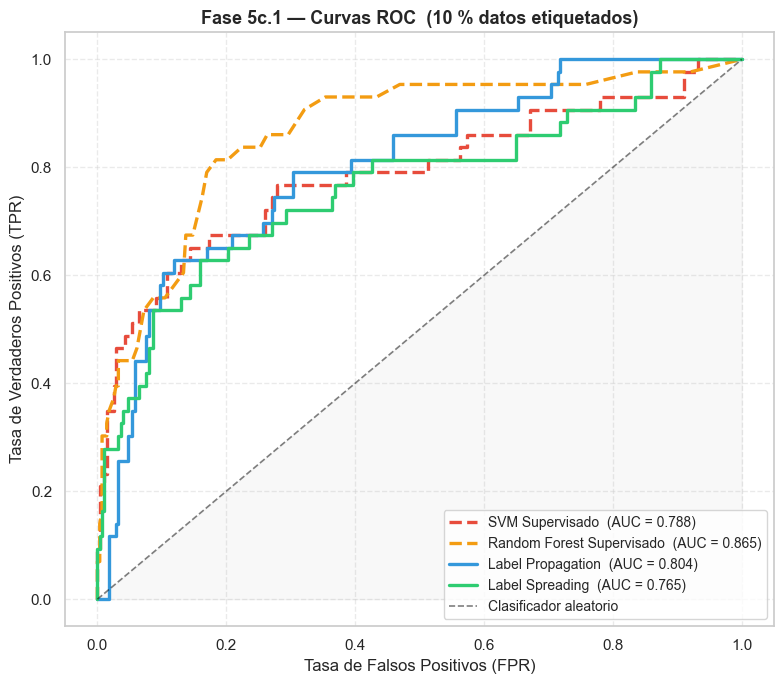

In [55]:
from sklearn.metrics import roc_curve, auc
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
import matplotlib.pyplot as plt
import numpy as np

# SVC necesita probability=True para predict_proba → reentrenar
proba_models = {
    'SVM Supervisado':           SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest Supervisado': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Label Propagation':         LabelPropagation(**best_config['label_propagation'], max_iter=1000),
    'Label Spreading':           LabelSpreading(**best_config['label_spreading'], alpha=0.2, max_iter=1000),
}

fig, ax = plt.subplots(figsize=(8, 7))

for name, model in proba_models.items():
    style = model_styles[name]
    if 'Supervisado' in name:
        model.fit(X_cm_lab, y_cm_lab)
    else:
        model.fit(X_cm_semi, y_cm_semi)

    proba = model.predict_proba(X_test_base)[:, 1]
    # LP/LS con kernel knn puede producir NaN en muestras fuera del grafo
    proba = np.nan_to_num(proba, nan=0.5)

    fpr, tpr, _ = roc_curve(y_test_base, proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=style['color'], linestyle=style['linestyle'], linewidth=2.4,
            label=f"{name}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.5, label='Clasificador aleatorio')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Fase 5c.1 — Curvas ROC  (10 % datos etiquetados)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#### 5c.2 — Propagación de etiquetas en espacio PCA

Para hacer visible el mecanismo interno de Label Propagation, se proyectan los datos de entrenamiento a 2 componentes principales y se muestra el estado *antes* y *después* de que el algoritmo propaga las etiquetas desde los puntos supervisados hacia los no supervisados.  
El tercer panel muestra el conjunto de test con la clase real y marca con una **×** las muestras que Label Propagation clasificó incorrectamente.

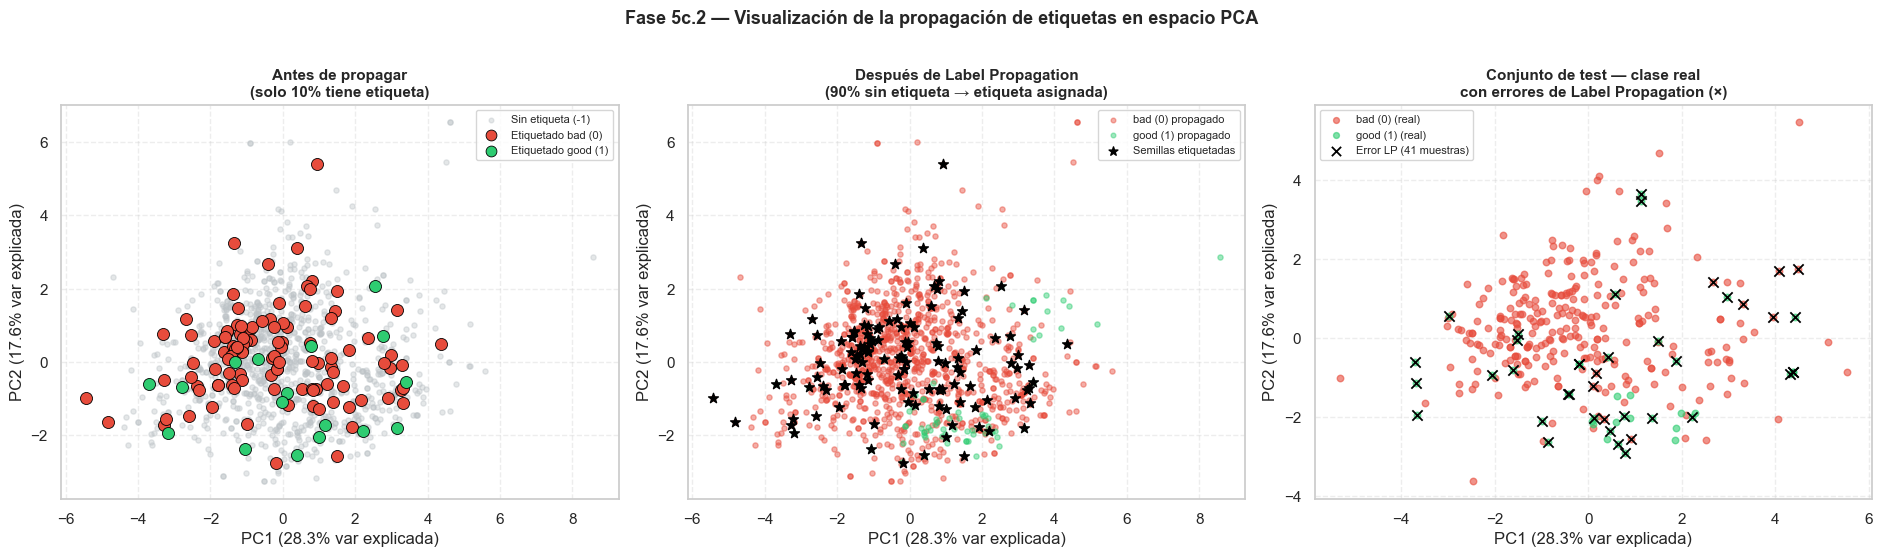

Semillas: 110 bad | 17 good
Propagados: 1089 bad | 63 good  (total no etiquetados: 1152)


In [56]:
from sklearn.decomposition import PCA
from sklearn.semi_supervised import LabelPropagation
import matplotlib.pyplot as plt
import numpy as np

# PCA ajustado sobre el conjunto de entrenamiento semi-supervisado (10%)
pca_vis      = PCA(n_components=2, random_state=42)
X_train_vis  = pca_vis.fit_transform(X_cm_semi)
X_test_vis   = pca_vis.transform(X_test_base)

labeled_mask   = y_cm_semi != -1
unlabeled_mask = ~labeled_mask

# Ajustar LP para obtener etiquetas propagadas (transduction_)
lp_vis = LabelPropagation(**best_config['label_propagation'], max_iter=1000)
lp_vis.fit(X_cm_semi, y_cm_semi)
y_propagated  = lp_vis.transduction_
y_pred_lp_test = lp_vis.predict(X_test_base)

class_colors = {0: '#e74c3c', 1: '#2ecc71'}
class_names  = {0: 'bad (0)', 1: 'good (1)'}
pct_var = pca_vis.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# ── Panel 1: antes de propagar ─────────────────────────────────────────
ax = axes[0]
ax.scatter(X_train_vis[unlabeled_mask, 0], X_train_vis[unlabeled_mask, 1],
           c='#bdc3c7', s=14, alpha=0.40, label='Sin etiqueta (-1)', zorder=1)
for cls in [0, 1]:
    mask = labeled_mask & (y_cm_semi == cls)
    ax.scatter(X_train_vis[mask, 0], X_train_vis[mask, 1],
               c=class_colors[cls], s=75, edgecolors='black', linewidths=0.6,
               label=f'Etiquetado {class_names[cls]}', zorder=3)
ax.set_title('Antes de propagar\n(solo 10% tiene etiqueta)',
             fontsize=11, fontweight='bold')
ax.set_xlabel(f'PC1 ({pct_var[0]:.1%} var explicada)')
ax.set_ylabel(f'PC2 ({pct_var[1]:.1%} var explicada)')
ax.legend(fontsize=8, markerscale=0.9)
ax.grid(linestyle='--', alpha=0.35)

# ── Panel 2: después — etiquetas propagadas ────────────────────────────
ax = axes[1]
for cls in [0, 1]:
    mask_prop = y_propagated == cls
    ax.scatter(X_train_vis[mask_prop, 0], X_train_vis[mask_prop, 1],
               c=class_colors[cls], s=14, alpha=0.45,
               label=f'{class_names[cls]} propagado', zorder=2)
# Resaltar semillas originales
ax.scatter(X_train_vis[labeled_mask, 0], X_train_vis[labeled_mask, 1],
           c='black', s=55, marker='*', zorder=4, label='Semillas etiquetadas')
ax.set_title('Después de Label Propagation\n(90% sin etiqueta → etiqueta asignada)',
             fontsize=11, fontweight='bold')
ax.set_xlabel(f'PC1 ({pct_var[0]:.1%} var explicada)')
ax.set_ylabel(f'PC2 ({pct_var[1]:.1%} var explicada)')
ax.legend(fontsize=8, markerscale=0.9)
ax.grid(linestyle='--', alpha=0.35)

# ── Panel 3: conjunto de test con errores LP ───────────────────────────
ax = axes[2]
for cls in [0, 1]:
    mask_t = y_test_base == cls
    ax.scatter(X_test_vis[mask_t, 0], X_test_vis[mask_t, 1],
               c=class_colors[cls], s=22, alpha=0.60,
               label=f'{class_names[cls]} (real)', zorder=2)
errors_test = y_pred_lp_test != y_test_base
ax.scatter(X_test_vis[errors_test, 0], X_test_vis[errors_test, 1],
           c='black', s=55, marker='x', linewidths=1.3,
           label=f'Error LP ({errors_test.sum()} muestras)', zorder=5)
ax.set_title('Conjunto de test — clase real\ncon errores de Label Propagation (×)',
             fontsize=11, fontweight='bold')
ax.set_xlabel(f'PC1 ({pct_var[0]:.1%} var explicada)')
ax.set_ylabel(f'PC2 ({pct_var[1]:.1%} var explicada)')
ax.legend(fontsize=8, markerscale=0.9)
ax.grid(linestyle='--', alpha=0.35)

plt.suptitle(
    'Fase 5c.2 — Visualización de la propagación de etiquetas en espacio PCA',
    fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

n_labeled_bad  = (y_cm_semi[labeled_mask] == 0).sum()
n_labeled_good = (y_cm_semi[labeled_mask] == 1).sum()
n_prop_bad  = (y_propagated[unlabeled_mask] == 0).sum()
n_prop_good = (y_propagated[unlabeled_mask] == 1).sum()
print(f'Semillas: {n_labeled_bad} bad | {n_labeled_good} good')
print(f'Propagados: {n_prop_bad} bad | {n_prop_good} good  '
      f'(total no etiquetados: {unlabeled_mask.sum()})')

#### 5c.3 — Importancia de features (Random Forest)

El Random Forest permite calcular la **importancia media de cada feature** (mean decrease impurity) a partir de los árboles entrenados solo con el 10% de datos etiquetados. Esta información es valiosa para entender qué características fisicoquímicas del vino el modelo considera más discriminativas para separar vinos `bad` de `good`, y contrasta con la correlación lineal calculada en el EDA.

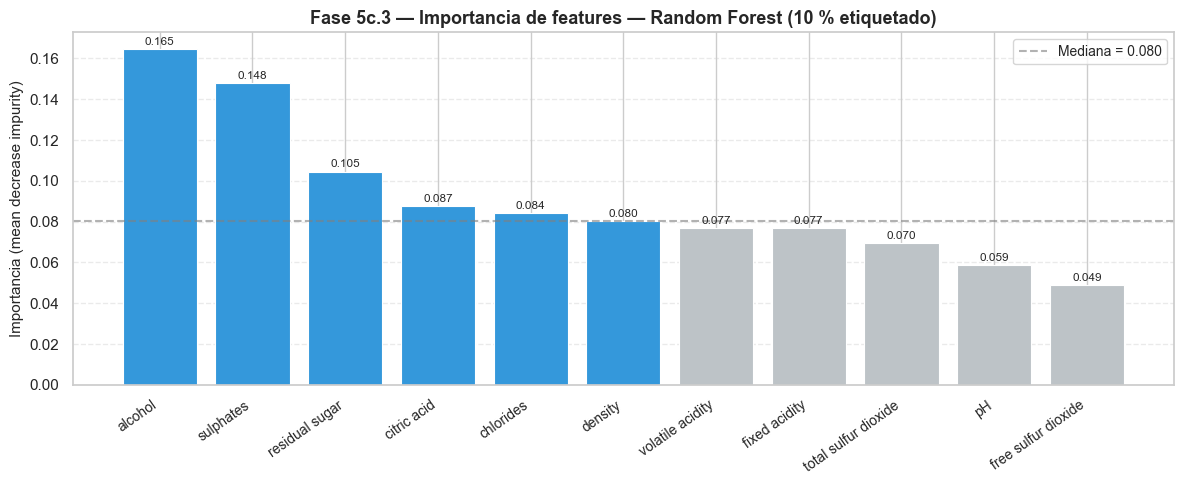

=== Top 5 features más importantes ===
  1. alcohol                  : 0.1645
  2. sulphates                : 0.1478
  3. residual sugar           : 0.1045
  4. citric acid              : 0.0875
  5. chlorides                : 0.0844


In [58]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Re-entrenar RF con el 10% etiquetado
rf_imp = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_imp.fit(X_cm_lab, y_cm_lab)

importances = rf_imp.feature_importances_
indices     = np.argsort(importances)[::-1]
median_imp  = np.median(importances)

fig, ax = plt.subplots(figsize=(12, 5))

colors_bar = ['#3498db' if importances[i] >= median_imp else '#bdc3c7'
              for i in indices]
bars = ax.bar(range(len(feature_cols)), importances[indices],
              color=colors_bar, edgecolor='white', linewidth=0.8)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels([feature_cols[i] for i in indices],
                   rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Importancia (mean decrease impurity)', fontsize=11)
ax.set_title('Fase 5c.3 — Importancia de features — Random Forest (10 % etiquetado)',
             fontsize=13, fontweight='bold')
ax.axhline(median_imp, color='gray', linestyle='--', alpha=0.6,
           label=f'Mediana = {median_imp:.3f}')
for bar, idx in zip(bars, indices):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{importances[idx]:.3f}',
            ha='center', va='bottom', fontsize=8.5)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('=== Top 5 features más importantes ===')
for rank, idx in enumerate(indices[:5], 1):
    print(f'  {rank}. {feature_cols[idx]:25s}: {importances[idx]:.4f}')